# Evaluating Model Performance

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# IMPORT LIBRARIES AND CONFIGURE PATHS
# Core scientific computing libraries for data analysis
import numpy as np          # Numerical operations and array handling
import scipy as sc          #
# Scientific computing functions (filtering, etc.)
import pandas as pd         # Data manipulation and analysis
from sklearn.metrics import matthews_corrcoef, roc_auc_score
from sklearn.model_selection import KFold
import statsmodels.formula.api as smf

# Visualization library
import matplotlib.pyplot as plt  # Plotting and figure generation
import seaborn as sns

# System and file handling utilities
import os
import sys
from os.path import join as ospj  # Cross-platform path joining
# from utils import *               # Custom utility functions

# --- Jupyter-friendly DynaSD path setup ---
# Attempt to find DynaSD repo relative to this notebook
import pathlib
notebook_path = pathlib.Path().resolve()
dynasd_root = (notebook_path / '..' / '..' / 'DynaSD').resolve()

if str(dynasd_root) not in sys.path:
    sys.path.insert(0, str(dynasd_root))

# Import models
from DynaSD.LiNDDA import LiNDDA

# Load configuration paths and settings
from config import Config
# Extract key paths: raw data, processed data, metadata, figures, and patient IDs
datapath, prodatapath, metapath, figpath, rid_hup = Config.deal(['datapath','prodatapath','metapath','figpath','rid_hup'])

## NDD heritage

In [ ]:
ndd_old = pd.read_csv(ospj(prodatapath,'res_series_list_ndd.csv'))

FileNotFoundError: [Errno 2] No such file or directory: '/Users/wojemann/local_data/dynasd_data/PROCESSED_DATA/res_series_list_ndd.csv'

<Axes: xlabel='hidden_size', ylabel='test_r2'>

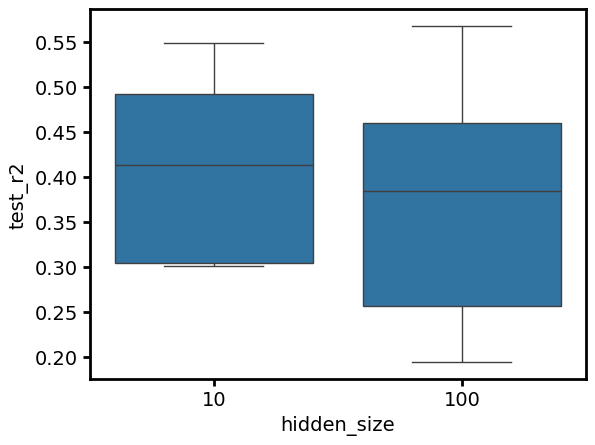

In [ ]:
sns.boxplot(ndd_old[ndd_old['duration']==60],x='hidden_size',y='test_r2')

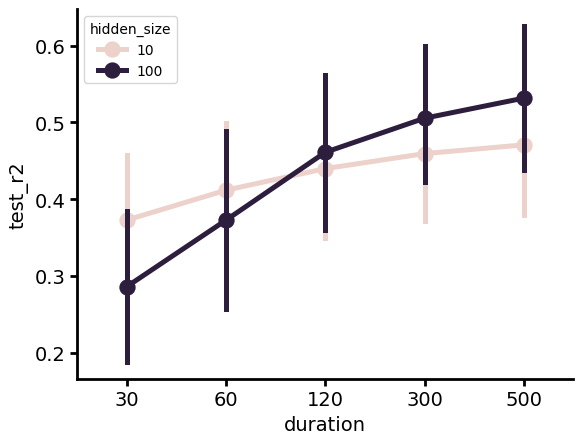

In [ ]:
sns.pointplot(x='duration',hue='hidden_size',y='test_r2',data=ndd_old[ndd_old['forecast_length']==1],legend=True)
sns.despine()

## MINDD hyperparameter optimization

In [ ]:
mindd_results = pd.read_csv(ospj(prodatapath, 'compiled_mindd_optimization_results.csv'))
mindd_results = mindd_results[(mindd_results['patient'] == 'HUP276')]
mindd_results = mindd_results[mindd_results.apply(lambda x: int(x.hidden_sizes.split(',')[0].replace(']','').replace('[','').split(' ')[0]) > x.n_channels*x.sequence_length*0.2,axis=1)]
top10 = mindd_results.nlargest(20, 'test_r2')
print(top10[['test_r2', 'train_r2','val_r2', 'hidden_sizes', 'weights','sequence_length']])

best_row = mindd_results.loc[mindd_results['test_r2'].idxmax()]
best_weights = best_row['weights']
print(f"Best test_r2: {best_row['test_r2']:.4f} with weights={best_weights}")

      test_r2  train_r2    val_r2   hidden_sizes     weights  sequence_length
838  0.846805  0.965526  0.903373  [23808, 3571]    (2, 0.3)              128
363  0.845000  0.958604  0.898688         [9523]      (0.8,)              128
350  0.841300  0.963947  0.899778   [9523, 3571]  (0.8, 0.3)              128
482  0.838377  0.955403  0.894399  [23808, 5952]    (2, 0.5)              128
146  0.836983  0.947585  0.888647         [5952]        (1,)               64
686  0.836541  0.951603  0.890698         [5952]      (0.5,)              128
274  0.826928  0.943451  0.882598        [11904]        (1,)              128
644  0.825952  0.941971  0.880302         [3571]      (0.3,)              128
411  0.824927  0.933344  0.875037         [4761]      (0.8,)               64
259  0.814732  0.938007  0.873368   [5952, 5952]  (0.5, 0.5)              128
816  0.814342  0.937076  0.872548   [5952, 9523]  (0.5, 0.8)              128
545  0.814245  0.933374  0.871234  [11904, 5952]    (1, 0.5)    

In [ ]:
mindd_results = pd.read_csv(ospj(prodatapath, 'compiled_mindd_optimization_results.csv'))
mindd_results = mindd_results[(mindd_results['patient'] == 'HUP065')]
mindd_results = mindd_results[mindd_results.apply(lambda x: int(x.hidden_sizes.split(',')[0].replace(']','').replace('[','').split(' ')[0]) > x.n_channels*x.sequence_length*0.3,axis=1)]
top10 = mindd_results.nlargest(20, 'test_r2')
print(top10[['test_r2', 'train_r2','val_r2', 'hidden_sizes', 'weights','sequence_length']])

best_row = mindd_results.loc[mindd_results['test_r2'].idxmax()]
best_weights = best_row['weights']
print(f"Best test_r2: {best_row['test_r2']:.4f} with weights={best_weights}")

      test_r2  train_r2    val_r2  hidden_sizes     weights  sequence_length
534  0.858744  0.902651  0.894761   [2816, 422]    (2, 0.3)              128
788  0.840073  0.860177  0.874863   [2816, 704]    (2, 0.5)              128
844  0.831381  0.816321  0.866048  [1126, 2816]    (0.8, 2)              128
23   0.828822  0.808358  0.860316  [1126, 1126]  (0.8, 0.8)              128
20   0.828103  0.803983  0.860048  [1126, 1408]    (0.8, 1)              128
228  0.824571  0.816775  0.857192  [2816, 1126]    (2, 0.8)              128
746  0.817343  0.794082  0.846728   [1126, 422]  (0.8, 0.3)              128
715  0.816621  0.786109  0.847647        [2816]        (2,)              128
603  0.816537  0.782077  0.845812   [1126, 704]  (0.8, 0.5)              128
287  0.812146  0.776206  0.843029  [1408, 1126]    (1, 0.8)              128
208  0.809768  0.755488  0.836746        [1408]        (1,)              128
850  0.804837  0.760632  0.834478   [1408, 704]    (1, 0.5)              128

In [ ]:
group_cols = ['sequence_length','weights']
ndd_data_avg = mindd_results.groupby(group_cols, dropna=False, as_index=False)[['train_r2','val_r2','test_r2']].mean()
best_params = []
max_r2 = ndd_data_avg['test_r2'].max()
best = ndd_data_avg[ndd_data_avg['test_r2'] == max_r2]
best_params.append(best)
if best_params:
    best_params_df = pd.concat(best_params, ignore_index=True)
    display(best_params_df.sort_values(['sequence_length']))
else:
    print("No best params found.")
    best_params_df = pd.DataFrame()

,sequence_length,weights,train_r2,val_r2,test_r2
0,128,"(2, 0.3)",0.902651,0.894761,0.858744


## NDD System Identification

In [ ]:
# ndd_data = pd.read_csv(ospj(prodatapath,'res_series_list_deep.csv'))
# ndd_data['model'] = ndd_data['model'].apply(lambda x: x.split('.')[-1][:-2])

In [ ]:
ndd_data = pd.read_csv(ospj(prodatapath,'compiled_ndd_optimization_results.csv'))
# ndd_data = ndd_data[ndd_data['patient']=='HUP065']
gin_data = ndd_data[ndd_data['model']=='GIN']
lin_data = ndd_data[ndd_data['model']=='LiNDDA']
min_data = ndd_data[ndd_data['model']=='MINDD']
lir_data = ndd_data[ndd_data.model=='LiRNDDA']

In [ ]:
ndd_data.patient.nunique()

5

<Axes: xlabel='duration', ylabel='test_r2'>

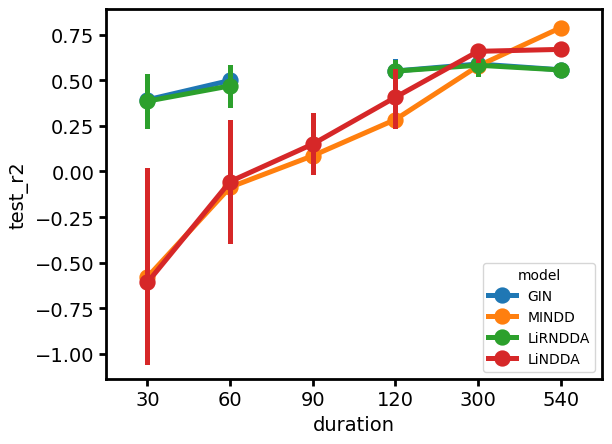

In [ ]:
sns.pointplot(x='duration',hue='model',y='test_r2',data=ndd_data[ndd_data['sequence_length']==128])

In [ ]:
group_cols = ['sequence_length','num_layers','num_stacks']
ndd_data_avg = gin_data[gin_data.duration == 120].groupby(group_cols, dropna=False, as_index=False)[['train_r2','val_r2','test_r2']].mean()
best_params = []
max_r2 = ndd_data_avg['test_r2'].max()
best = ndd_data_avg[ndd_data_avg['test_r2'] == max_r2]
best_params.append(best)
if best_params:
    best_params_df = pd.concat(best_params, ignore_index=True)
    display(best_params_df.sort_values(['sequence_length']))
else:
    print("No best params found.")
    best_params_df = pd.DataFrame()

,sequence_length,num_layers,num_stacks,train_r2,val_r2,test_r2
0,32,1.0,1.0,0.455521,0.53808,0.574985


<Axes: xlabel='sequence_length', ylabel='test_r2'>

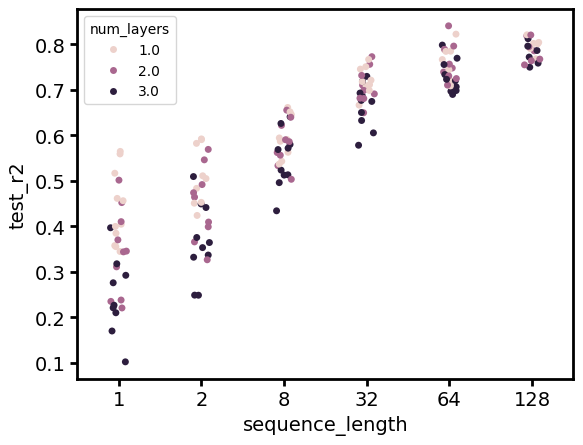

In [ ]:
sns.stripplot(x='sequence_length',y='test_r2',hue='num_layers',data=min_data[min_data['duration']==540])

<Axes: xlabel='sequence_length', ylabel='train_s'>

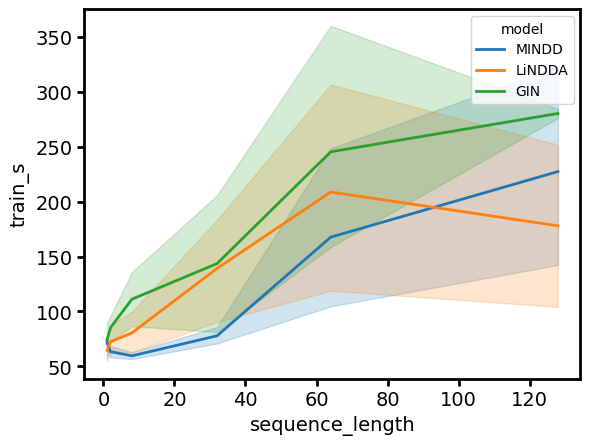

In [ ]:
sns.lineplot(x='sequence_length',hue='model',y='train_s',data=ndd_data[(ndd_data['duration']==540)&(ndd_data.model != 'LiRNDDA')])

<Axes: xlabel='sequence_length', ylabel='test_r2'>

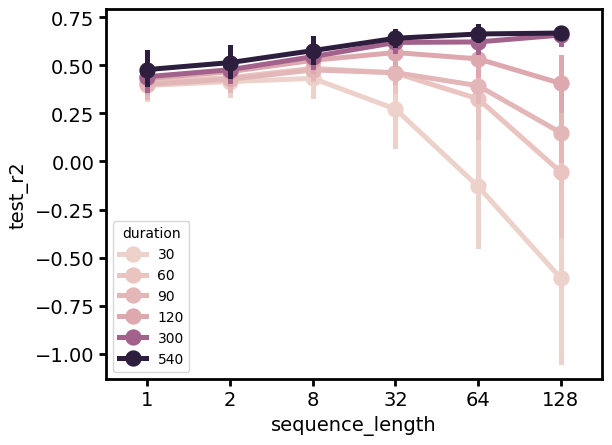

In [ ]:
sns.pointplot(lin_data,x='sequence_length',hue='duration',y='test_r2')

(0.0, 1.0)

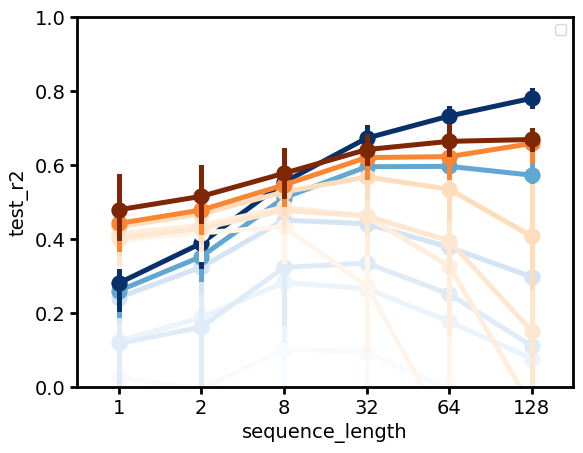

In [ ]:
sns.pointplot(min_data[(min_data['param_scale']==1)],x='sequence_length',y='test_r2',hue='duration',palette='Blues')
sns.pointplot(lin_data,x='sequence_length',y='test_r2',hue='duration',palette='Oranges')
plt.legend([])
plt.ylim(0,1)

In [ ]:
group_cols = ['model','duration','sequence_length','num_layers','param_scale','num_stacks','forecast_length']
ndd_data_avg = ndd_data.groupby(group_cols, dropna=False, as_index=False)[['train_r2','val_r2','test_r2']].mean()
best_params = []
for model in ndd_data_avg['model'].unique():
    for duration in ndd_data_avg['duration'].unique():
        subset = ndd_data_avg[(ndd_data_avg['model'] == model) & (ndd_data_avg['duration'] == duration)]
        if subset.empty: continue
        max_r2 = subset['test_r2'].max()
        best = subset[subset['test_r2'] == max_r2]
        best_params.append(best)
if best_params:
    best_params_df = pd.concat(best_params, ignore_index=True)
    display(best_params_df.sort_values(['model','duration','sequence_length']))
else:
    print("No best params found.")
    best_params_df = pd.DataFrame()


,model,duration,sequence_length,num_layers,param_scale,num_stacks,forecast_length,train_r2,val_r2,test_r2
0,GIN,30,64,1.0,NaN,1.0,1,0.378659,0.394394,0.409219
1,GIN,60,32,1.0,NaN,1.0,1,0.434224,0.462267,0.507847
2,GIN,120,32,1.0,NaN,1.0,1,0.455521,0.538080,0.574985
3,GIN,300,128,1.0,NaN,1.0,1,0.469911,0.551114,0.588645
4,GIN,540,32,1.0,NaN,1.0,1,0.471488,0.606583,0.608054
5,LiNDDA,30,8,NaN,NaN,NaN,1,0.434550,0.504924,0.432667
6,LiNDDA,60,8,NaN,NaN,NaN,1,0.431026,0.511783,0.484901
10,LiNDDA,90,8,NaN,NaN,NaN,1,0.425589,0.504898,0.476701
7,LiNDDA,120,32,NaN,NaN,NaN,1,0.527712,0.622853,0.567271
8,LiNDDA,300,128,NaN,NaN,NaN,1,0.630197,0.677594,0.657976


<Axes: xlabel='sequence_length', ylabel='test_r2'>

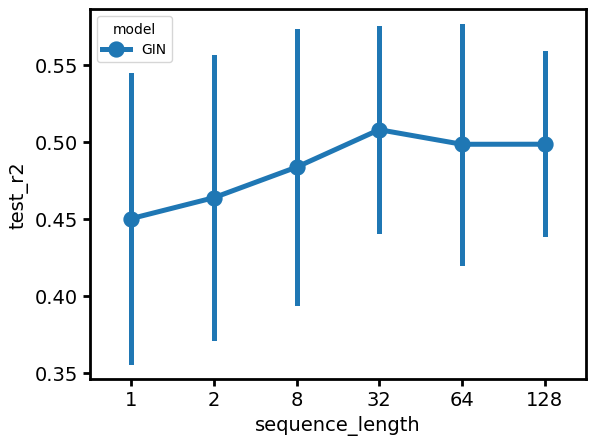

In [ ]:
sns.pointplot(x='sequence_length',hue='model',y='test_r2',data=gin_data[(gin_data['duration']==60)])

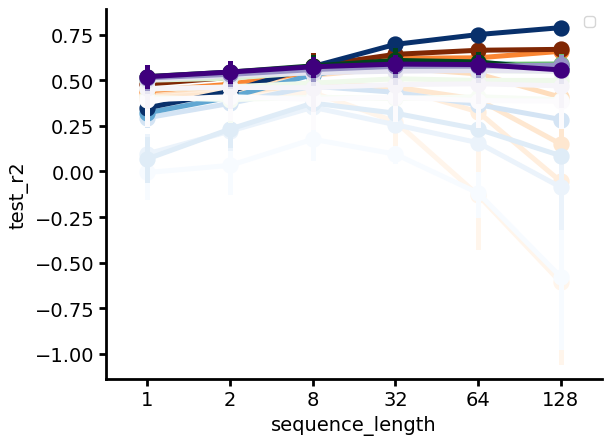

In [ ]:
sns.pointplot(x='sequence_length',hue='duration',y='test_r2',data=lin_data[lin_data['forecast_length']==1],palette='Oranges')
sns.pointplot(x='sequence_length',hue='duration',y='test_r2',data=min_data[min_data['forecast_length']==1],palette='Blues')
sns.pointplot(x='sequence_length',hue='duration',y='test_r2',data=gin_data[gin_data['forecast_length']==1],palette='Greens')
sns.pointplot(x='sequence_length',hue='duration',y='test_r2',data=lir_data[lir_data['forecast_length']==1],palette='Purples')
plt.legend([])
sns.despine()

<Axes: xlabel='model', ylabel='train_s'>

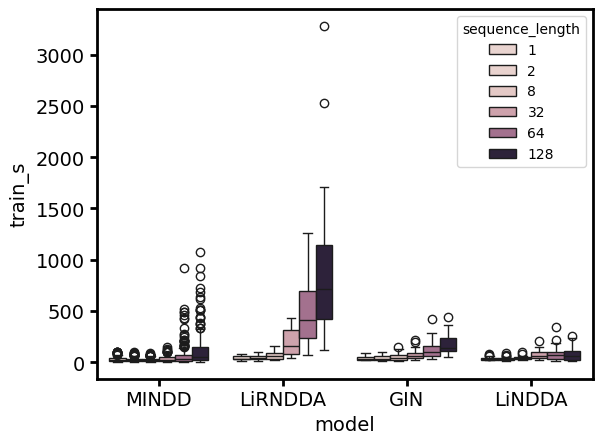

In [ ]:
sns.boxplot(x='model',hue='sequence_length',y='train_s',data=ndd_data)

## Validation performance

In [ ]:
shallow_data = pd.read_csv(ospj(prodatapath, "benchmark_model_validation_results_v7.csv"))
shallow_melted = pd.melt(shallow_data, id_vars=['model'], value_vars=['auc','iou_f1','iou_phi','iou_sensitivity','iou_specificity','iou_precision','iou_recall','f1_f1','f1_phi','f1_sensitivity','f1_specificity','f1_precision','f1_recall'], var_name='metric', value_name='value')

In [ ]:
shallow_data.columns

Index(['patient', 'onset', 'split', 'stim', 'model', 'auc', 'iou_threshold',
       'iou_f1', 'iou_phi', 'iou_sensitivity', 'iou_specificity',
       'iou_precision', 'iou_recall', 'f1_threshold', 'f1_f1', 'f1_phi',
       'f1_sensitivity', 'f1_specificity', 'f1_precision', 'f1_recall',
       'phi_threshold', 'phi_f1', 'phi_phi', 'phi_sensitivity',
       'phi_specificity', 'phi_precision', 'phi_recall'],
      dtype='object')

model
ABSSLP     0.667409
HFER       0.674952
IMPRINT    0.795852
WVNT       0.825842
Name: auc, dtype: float64


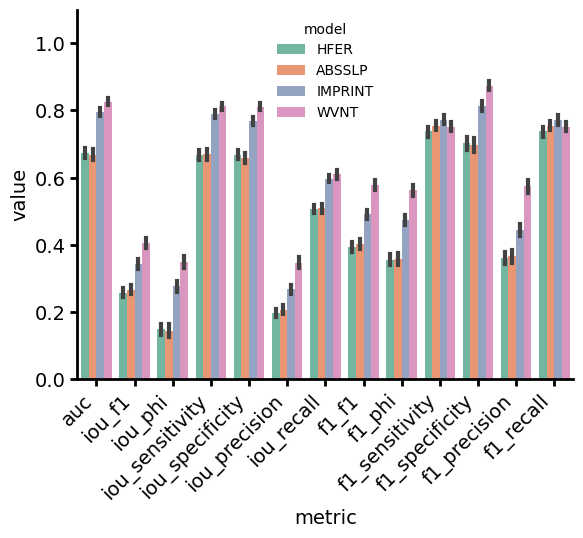

In [ ]:
# sns.barplot(x='metric',y='value',hue='model',data=shallow_melted,palette=['purple','blue','green','red'],hue_order=['HFER','ABSSLP','IMPRINT','WVNT'])
sns.barplot(x='metric',y='value',hue='model',data=shallow_melted,palette='Set2',hue_order=['HFER','ABSSLP','IMPRINT','WVNT'])
print(shallow_data.groupby('model').auc.mean())

# sns.stripplot(x='metric',y='value',hue='model',data=shallow_melted, dodge=True, jitter=True,alpha=0.1,color='gray',size=3,legend=False)
plt.ylim([0,1.1])
plt.xticks(rotation=45,ha='right')
sns.despine()

In [ ]:
# sns.barplot(x='model',y='threshold',data=shallow_data,palette=['blue','green','red'])
# sns.stripplot(x='model',y='threshold',data=shallow_data, dodge=True, jitter=True,alpha=0.1,color='gray',size=3)
# sns.despine()
iou_benchmark_thresholds = shallow_data.groupby(['model','patient']).agg({'iou_threshold':'median'}).reset_index().groupby('model').agg({'iou_threshold':'median'}).reset_index()
f1_benchmark_thresholds = shallow_data.groupby(['model','patient']).agg({'f1_threshold':'median'}).reset_index().groupby('model').agg({'f1_threshold':'median'}).reset_index()
phi_benchmark_thresholds = shallow_data.groupby(['model','patient']).agg({'phi_threshold':'median'}).reset_index().groupby('model').agg({'phi_threshold':'median'}).reset_index()
print(iou_benchmark_thresholds)
print(f1_benchmark_thresholds)
print(phi_benchmark_thresholds)

     model  iou_threshold
0   ABSSLP     230.419769
1     HFER       9.711496
2  IMPRINT       5.737759
3     WVNT       0.367146
     model  f1_threshold
0   ABSSLP    268.801757
1     HFER     14.238726
2  IMPRINT      7.229341
3     WVNT      0.492918
     model  phi_threshold
0   ABSSLP     279.183993
1     HFER      12.464746
2  IMPRINT       6.950998
3     WVNT       0.494377


In [ ]:
f1_benchmark_thresholds.to_csv(ospj(prodatapath,'benchmark_val_thresholds_f1_median.csv'))
iou_benchmark_thresholds.to_csv(ospj(prodatapath,'benchmark_val_thresholds_iou_median.csv'))
phi_benchmark_thresholds.to_csv(ospj(prodatapath,'benchmark_val_thresholds_phi_median.csv'))

## Generalized Validation performance

In [ ]:
val_data = pd.read_csv(ospj(prodatapath, "benchmark_val_analysis_results_f1_v4.csv"))

In [ ]:
val_data.onset.nunique()

1030

In [ ]:
val_data_onset = val_data.melt(id_vars=['patient','model'], value_vars=['sensitivity','specificity','f1','phi'], var_name='metric', value_name='value')
val_data_spread = val_data.melt(id_vars=['patient','model'], value_vars=['med_soz_spread_rank_pct','avg_soz_spread_rank_pct'], var_name='metric', value_name='value')
val_data_latency = val_data.melt(id_vars=['patient','model'], value_vars=['med_soz_recruitment_latency','avg_soz_recruitment_latency'], var_name='metric', value_name='value')

/tmp/ipykernel_37417/4198091649.py:2: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:gray'` for the same effect.

  sns.stripplot(x='metric',y='value',hue='model',data=val_data_onset,color='gray',jitter=True,alpha=0.1,legend=False,size=2,dodge=True)


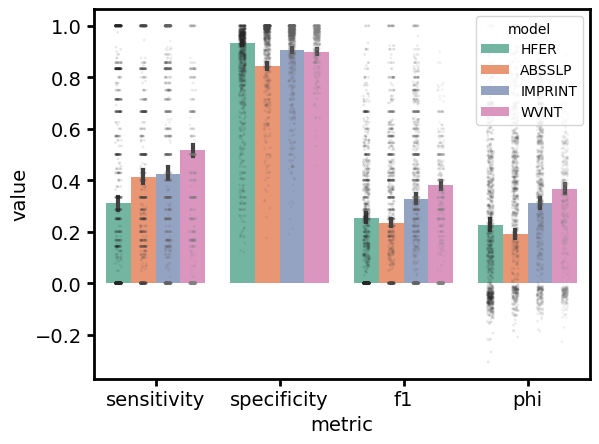

/tmp/ipykernel_37417/4198091649.py:6: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:gray'` for the same effect.

  sns.stripplot(x='metric',y='value',hue='model',data=val_data_spread,color='gray',jitter=True,alpha=0.1,legend=False,size=2,dodge=True)


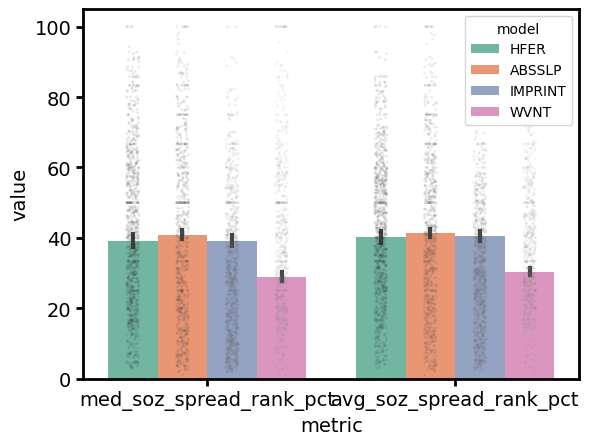

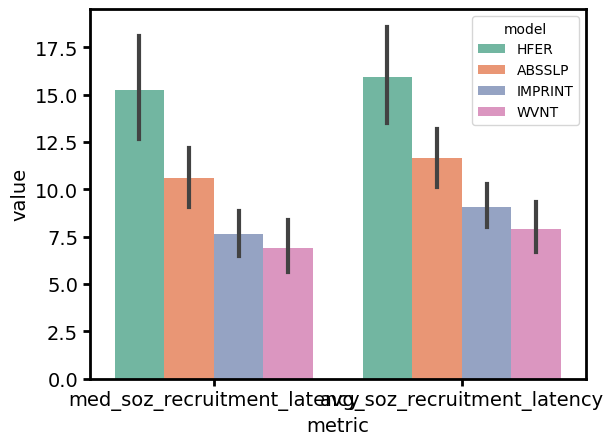

In [ ]:
sns.barplot(x='metric',y='value',hue='model',data=val_data_onset,palette='Set2',hue_order=['HFER','ABSSLP','IMPRINT','WVNT'])
sns.stripplot(x='metric',y='value',hue='model',data=val_data_onset,color='gray',jitter=True,alpha=0.1,legend=False,size=2,dodge=True)
plt.show()

sns.barplot(x='metric',y='value',hue='model',data=val_data_spread,palette='Set2',hue_order=['HFER','ABSSLP','IMPRINT','WVNT'])
sns.stripplot(x='metric',y='value',hue='model',data=val_data_spread,color='gray',jitter=True,alpha=0.1,legend=False,size=2,dodge=True)
plt.show()

sns.barplot(x='metric',y='value',hue='model',data=val_data_latency,palette='Set2',hue_order=['HFER','ABSSLP','IMPRINT','WVNT'])
# sns.stripplot(x='metric',y='value',hue='model',data=val_data_latency,color='gray',jitter=True,alpha=0.1,legend=False,size=2,dodge=True)
plt.show()

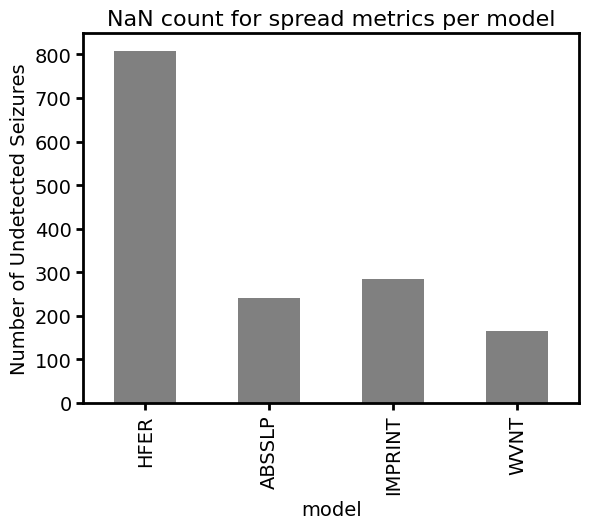

In [ ]:
spread_nan_counts = val_data_spread[val_data_spread['value'].isna()].groupby('model').size()
spread_nan_counts = spread_nan_counts.reindex(['HFER','ABSSLP','IMPRINT','WVNT']).fillna(0)
spread_nan_counts.plot(kind='bar',color='gray')
plt.ylabel('Number of Undetected Seizures')
plt.title('NaN count for spread metrics per model')
plt.show()


## NDD performance

Initial rows: 8312
model
GIN_mse_sl12_fl1      0.868289
GIN_mse_sl8_fl1       0.868023
LiNDDA_mse_sl1_fl1    0.862401
LiNDDA_mse_sl2_fl1    0.870918
LiNDDA_mse_sl3_fl2    0.872924
LiNDDA_mse_sl4_fl3    0.872355
LiNDDA_mse_sl5_fl4    0.869301
NDD_mse_sl12_fl1      0.845193
Name: auc, dtype: float64
model
GIN_mse_sl12_fl1      0.502004
GIN_mse_sl8_fl1       0.501617
LiNDDA_mse_sl1_fl1    0.501549
LiNDDA_mse_sl2_fl1    0.502845
LiNDDA_mse_sl3_fl2    0.504691
LiNDDA_mse_sl4_fl3    0.503318
LiNDDA_mse_sl5_fl4    0.498634
NDD_mse_sl12_fl1      0.485850
Name: auprc_normalized, dtype: float64


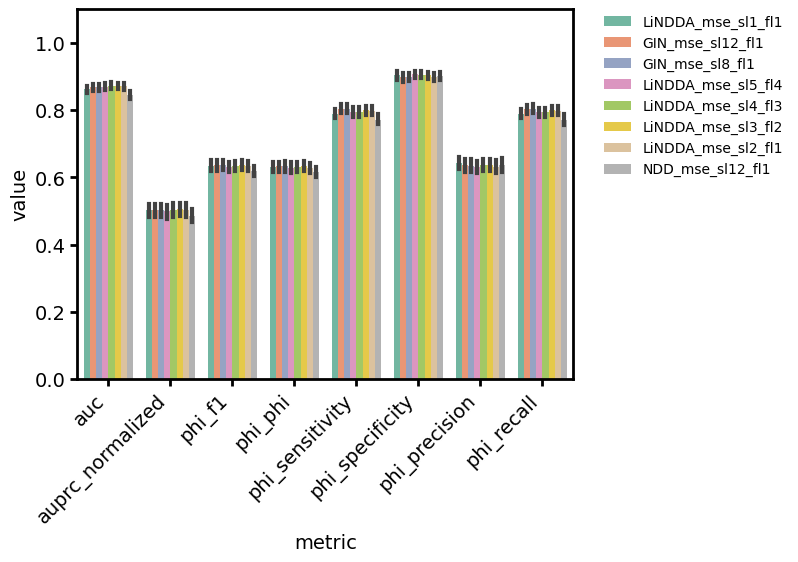

In [ ]:
# ndd_data = pd.read_csv(ospj(prodatapath, 'ndd_model_validation_results.csv'))
# ndd_data_latter = pd.read_csv(ospj(prodatapath, 'ndd_model_validation_results_latter.csv'))
# ndd_data_lat_server = pd.read_csv(ospj(prodatapath, 'ndd_model_validation_results_latter_server.csv'))

# ndd_data = pd.concat([ndd_data,ndd_data_latter,ndd_data_lat_server])
# ndd_data_32 = pd.read_csv(ospj(prodatapath, 'ndd_model_validation_results_seq32.csv'))
# ndd_data_32s = pd.read_csv(ospj(prodatapath, 'ndd_model_validation_results_seq32_server.csv'))
# ndd_data = pd.concat([ndd_data,ndd_data_32,ndd_data_32s])
# ndd_data = pd.read_csv(ospj(prodatapath,'ndd_model_validation_results_100.csv'))
# mindd_data = pd.read_csv(ospj(prodatapath,f"mindd_model_validation_results_100.csv"))
# ndd_data = pd.concat([ndd_data,mindd_data])
ndd_data = pd.read_csv(ospj(prodatapath,'ndd_model_validation_results_v8.csv'))
# ndd_data = ndd_data[(ndd_data.patient.isin(dummy.patient)) & (ndd_data.onset.isin(dummy.onset))]
# ndd_data = ndd_data[ndd_data.onset.isin(dummy.onset)]
# ndd_data_temp = pd.read_csv(ospj(prodatapath,'ndd_model_validation_results_v2_linddaseq.csv'))
# ndd_data = pd.concat([ndd_data,ndd_data_temp])
print(f"Initial rows: {len(ndd_data)}")

metadata = pd.read_csv(ospj(metapath,'metadata_v7_BIDS.csv'))
metadata['patient'] = metadata['Patient']
metadata['stim'] = metadata['stim'].fillna(0)
metadata['onset'] = metadata['onset'].astype(int)

# print(f"\nMetadata duplicates on 'onset': {metadata['onset'].duplicated().sum()}")
# print(f"Metadata duplicates on ['patient','onset']: {metadata[['patient','onset']].duplicated().sum()}")

# First merge
ndd_data = ndd_data.merge(metadata[['patient', 'onset', 'stim']], on=['patient', 'onset'], how='left')
# print(f"After first merge: {len(ndd_data)} rows")

# # Check for duplicates (excluding stim column)
key_cols = [col for col in ndd_data.columns if col != 'stim']
# duplicates_mask = ndd_data.duplicated(subset=key_cols, keep=False)
# print(f"\nTotal duplicate rows: {duplicates_mask.sum()}")

# if duplicates_mask.sum() > 0:
#     print("\nPatients/seizures with duplicate rows:")
#     dup_patients_onsets = ndd_data[duplicates_mask][['patient','onset']].drop_duplicates().sort_values(['patient','onset'])
#     print(f"Total unique patient/onset combos with duplicates: {len(dup_patients_onsets)}")
#     display(dup_patients_onsets)
    
#     print("\nSample of duplicate rows:")
#     display(ndd_data[duplicates_mask].sort_values(['patient','onset','model']).head(20))
    
#     # Show what columns vary in duplicates
#     print("\nColumns that vary in duplicate groups:")
#     dup_subset = ndd_data[duplicates_mask]
#     for col in ndd_data.columns:
#         n_unique_per_group = dup_subset.groupby(key_cols)[col].nunique()
#         if (n_unique_per_group > 1).any():
#             print(f"  {col}: varies")

# Handle duplicates by taking max stim value
ndd_data = ndd_data.sort_values('stim', ascending=False).drop_duplicates(subset=key_cols, keep='first')
# print(f"\nAfter deduplication: {len(ndd_data)} rows")

ndd_data = ndd_data[ndd_data.split == 1] 
ndd_data.loc[ndd_data.model.apply(lambda x: 'onset' in x),'model'] = ndd_data.loc[ndd_data.model.apply(lambda x: 'onset' in x),'model'].apply(lambda x: x.replace('onset_',''))
ndd_data['model'] = ndd_data['model'].astype(str) + '_sl' + ndd_data['sequence'].astype(str) + '_fl' + ndd_data['forecast'].astype(str)
ndd_data = ndd_data[ndd_data.model.apply(lambda x: '_mse_z' not in x)] # ('_mse_s' in x) ('prob_s' in x) and ('fl16' not in x) ('_mse_s' in x) and  ('LiN' in x) and ('LiN' not in x) andand ('_mse_s' in x))
# value_vars = ['auc','iou_f1','iou_phi','iou_sensitivity','iou_specificity','iou_precision','iou_recall']
value_vars = ['auc','auprc_normalized','phi_f1','phi_phi','phi_sensitivity','phi_specificity','phi_precision','phi_recall']
# value_vars = ['auc','f1_f1','f1_phi','f1_sensitivity','f1_specificity','f1_precision','f1_recall']
ndd_melted = pd.melt(ndd_data, id_vars=['model'], value_vars=value_vars, var_name='metric', value_name='value')

print(ndd_data.groupby('model').auc.mean())
print(ndd_data.groupby('model').auprc_normalized.mean())

sns.barplot(x='metric',y='value',hue='model',data=ndd_melted,palette='Set2',estimator=np.mean)
plt.ylim([0,1.1])
plt.xticks(rotation=45,ha='right')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.show()

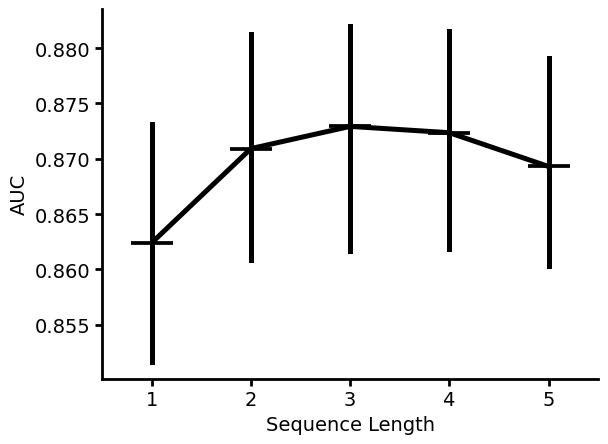

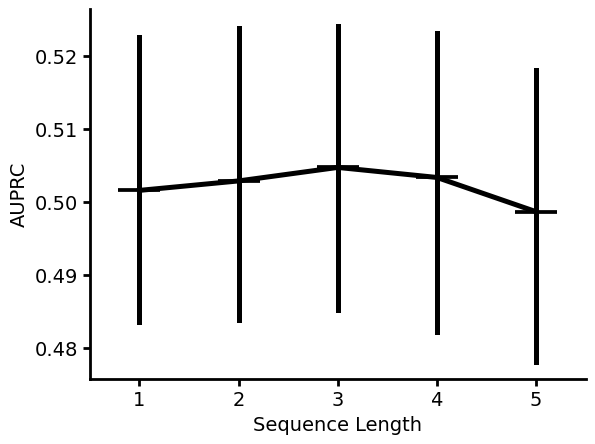

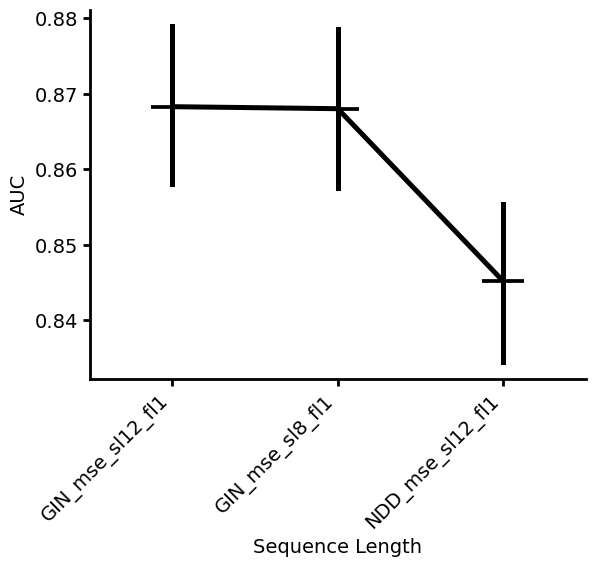

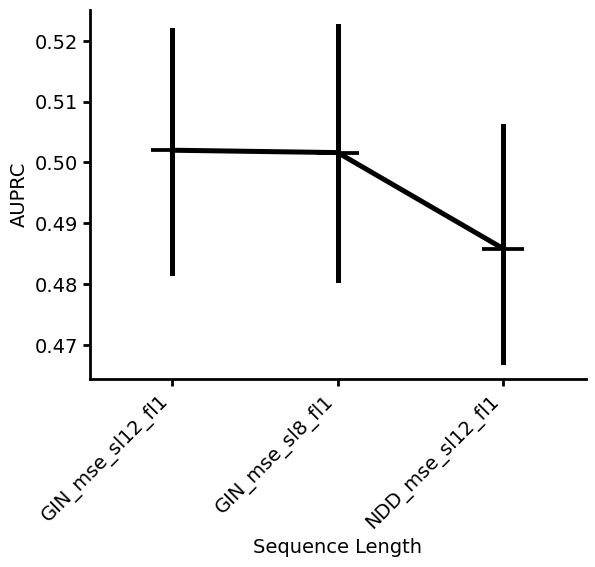

In [ ]:
metric_data = ndd_melted[ndd_melted.model.apply(lambda x: (('LiN' in x)) and (('_mse_s' in x) or ('_prob' in x)))]
metric_data = metric_data.sort_values('model')
auc_data = metric_data[metric_data.metric == 'auc'] # and ('sl12' in x) ('prob_s' in x) and ('fl16' not in x)  and  ('LiN' in x) and ('LiN' not in x) andand ('_mse_s' in x))
# sns.stripplot(y='value',x = 'model',data=metric_data,dodge=True, color = 'gray',alpha=0.1)
sns.pointplot(y='value',x = 'model',data=auc_data,dodge=True, color ='black',marker = '_', markersize=30,estimator=np.mean)
plt.xticks(range(metric_data.model.nunique()),np.arange(metric_data.model.nunique())+1)
plt.xlabel('Sequence Length')
plt.ylabel('AUC')
sns.despine()
plt.savefig(ospj(figpath,'lindda_auc.pdf'))
plt.show()
auprc_data = metric_data[metric_data.metric == 'auprc_normalized']
sns.pointplot(y='value',x = 'model',data=auprc_data,dodge=True, color ='black',marker = '_', markersize=30,estimator=np.mean)
plt.xticks(range(metric_data.model.nunique()),np.arange(metric_data.model.nunique())+1)
plt.xlabel('Sequence Length')
plt.ylabel('AUPRC')
sns.despine()
plt.savefig(ospj(figpath,'lindda_auprc_.pdf'))
plt.show()

metric_data = ndd_melted[ndd_melted.model.apply(lambda x: (('GIN' in x) or ('NDD_' in x)) and ('MINDD' not in x) and (('_mse_s' in x)))]
metric_data = metric_data.sort_values('model')
auc_data = metric_data[metric_data.metric == 'auc'] # and ('sl12' in x) ('prob_s' in x) and ('fl16' not in x)  and  ('LiN' in x) and ('LiN' not in x) andand ('_mse_s' in x))
# sns.stripplot(y='value',x = 'model',data=metric_data,dodge=True, color = 'gray',alpha=0.1)
sns.pointplot(y='value',x = 'model',data=auc_data,dodge=True, color ='black',marker = '_', markersize=30,estimator=np.mean)
# plt.xticks(range(metric_data.model.nunique()),np.arange(metric_data.model.nunique())+1)
plt.xticks(rotation=45,ha='right')
plt.xlabel('Sequence Length')
plt.ylabel('AUC')
sns.despine()
plt.savefig(ospj(figpath,'gin_auc.pdf'))
plt.show()
auprc_data = metric_data[metric_data.metric == 'auprc_normalized']
sns.pointplot(y='value',x = 'model',data=auprc_data,dodge=True, color ='black',marker = '_', markersize=30,estimator=np.mean)
# plt.xticks(range(metric_data.model.nunique()),np.arange(metric_data.model.nunique())+1)
plt.xticks(rotation=45,ha='right')
plt.xlabel('Sequence Length')
plt.ylabel('AUPRC')
sns.despine()
plt.savefig(ospj(figpath,'gin_auprc.pdf'))
plt.show()

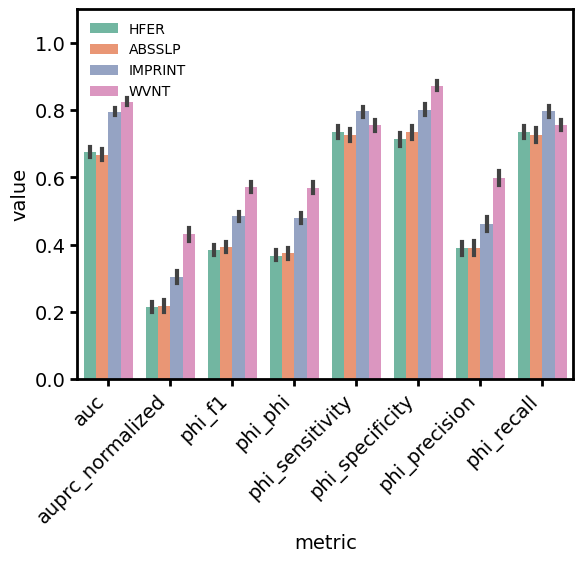

In [ ]:
benchmark_data = pd.read_csv(ospj(prodatapath, 'benchmark_model_validation_results_v8.csv'))
benchmark_data = benchmark_data[benchmark_data.onset.isin(ndd_data.onset)]
benchmark_melted = benchmark_data.melt(id_vars=['model'], value_vars=value_vars, var_name='metric', value_name='value')

sns.barplot(x='metric',y='value',hue='model',data=benchmark_melted,palette='Set2',hue_order=['HFER','ABSSLP','IMPRINT','WVNT'])
plt.ylim([0,1.1])
plt.xticks(rotation=45,ha='right')
plt.legend(loc='upper left')
plt.show()

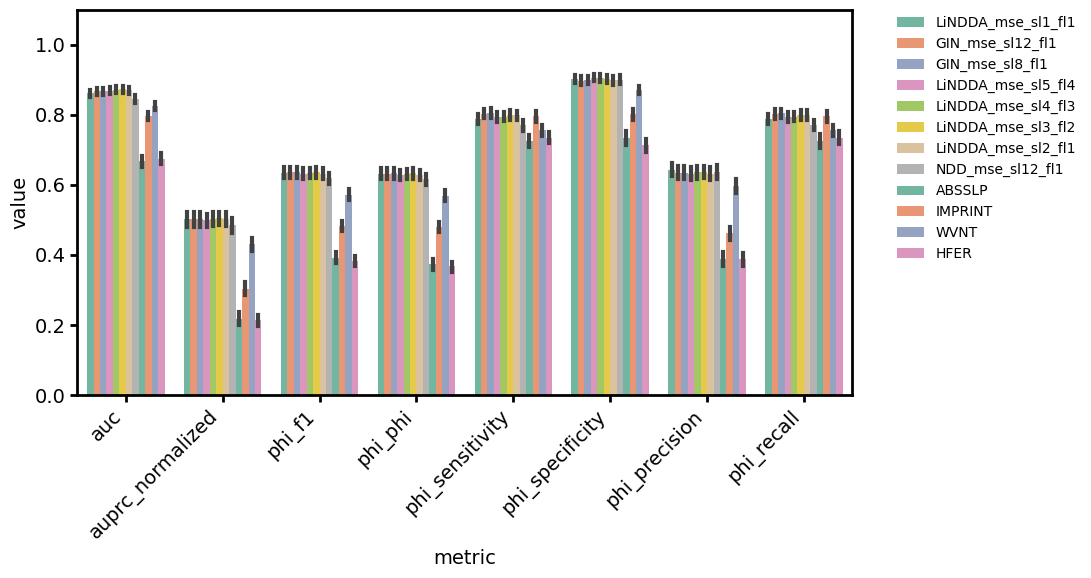

In [ ]:
all_data = pd.concat([ndd_melted,benchmark_melted],axis=0).reset_index(drop=True)
fig,ax = plt.subplots(figsize=(10,5))
sns.barplot(x='metric',y='value',hue='model',data=all_data,palette='Set2',estimator=np.mean)
plt.ylim([0,1.1])
plt.xticks(rotation=45,ha='right')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.show()

In [ ]:
# Find the model with the highest average performance for each metric
best_models_per_metric = all_data.groupby(['metric', 'model'])['value'].mean().reset_index()
top3_models = best_models_per_metric.groupby('metric').apply(lambda x: x.nlargest(5, 'value')).reset_index(drop=True)
print("Top 3 models for each metric:")
print(top3_models)

Top 3 models for each metric:
              metric               model     value
0                auc  LiNDDA_mse_sl3_fl2  0.872924
1                auc  LiNDDA_mse_sl4_fl3  0.872355
2                auc  LiNDDA_mse_sl2_fl1  0.870918
3                auc  LiNDDA_mse_sl5_fl4  0.869301
4                auc    GIN_mse_sl12_fl1  0.868289
5   auprc_normalized  LiNDDA_mse_sl3_fl2  0.504691
6   auprc_normalized  LiNDDA_mse_sl4_fl3  0.503318
7   auprc_normalized  LiNDDA_mse_sl2_fl1  0.502845
8   auprc_normalized    GIN_mse_sl12_fl1  0.502004
9   auprc_normalized     GIN_mse_sl8_fl1  0.501617
10            phi_f1  LiNDDA_mse_sl3_fl2  0.636748
11            phi_f1     GIN_mse_sl8_fl1  0.636366
12            phi_f1    GIN_mse_sl12_fl1  0.636197
13            phi_f1  LiNDDA_mse_sl1_fl1  0.634647
14            phi_f1  LiNDDA_mse_sl4_fl3  0.634505
15           phi_phi  LiNDDA_mse_sl3_fl2  0.633151
16           phi_phi     GIN_mse_sl8_fl1  0.632891
17           phi_phi    GIN_mse_sl12_fl1  0.632469
1

/var/folders/9k/4csk57xn1q1csdw28xvkxm200000gn/T/ipykernel_5198/633319701.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top3_models = best_models_per_metric.groupby('metric').apply(lambda x: x.nlargest(5, 'value')).reset_index(drop=True)


In [ ]:
all_threshs = []
for combine in ['median', 'mean']:
    iou_benchmark_thresholds = benchmark_data.groupby(['model', 'patient']).agg({'iou_threshold': combine}).reset_index().groupby('model').agg({'iou_threshold': combine}).reset_index()
    f1_benchmark_thresholds = benchmark_data.groupby(['model', 'patient']).agg({'f1_threshold': combine}).reset_index().groupby('model').agg({'f1_threshold': combine}).reset_index()
    phi_benchmark_thresholds = benchmark_data.groupby(['model', 'patient']).agg({'phi_threshold': combine}).reset_index().groupby('model').agg({'phi_threshold': combine}).reset_index()
    phi_plateau_benchmark_thresholds = benchmark_data.groupby(['model', 'patient']).agg({'phi_threshold_plateau': combine}).reset_index().groupby('model').agg({'phi_threshold_plateau': combine}).reset_index()
    f1_plateau_benchmark_thresholds = benchmark_data.groupby(['model', 'patient']).agg({'f1_threshold_plateau': combine}).reset_index().groupby('model').agg({'f1_threshold_plateau': combine}).reset_index()

    # Calculate the aggregated thresholds for each metric
    iou_ndd_thresholds = ndd_data.groupby(['model', 'patient']).agg({'iou_threshold': combine}).reset_index().groupby('model').agg({'iou_threshold': combine}).reset_index()
    iou_ndd_thresholds = iou_ndd_thresholds.rename(columns={'iou_threshold': 'threshold'})
    iou_ndd_thresholds['metric'] = 'iou'
    iou_ndd_thresholds['aggregation'] = combine

    f1_ndd_thresholds = ndd_data.groupby(['model', 'patient']).agg({'f1_threshold': combine}).reset_index().groupby('model').agg({'f1_threshold': combine}).reset_index()
    f1_ndd_thresholds = f1_ndd_thresholds.rename(columns={'f1_threshold': 'threshold'})
    f1_ndd_thresholds['metric'] = 'f1'
    f1_ndd_thresholds['aggregation'] = combine

    f1_plateau_ndd_thresholds = ndd_data.groupby(['model', 'patient']).agg({'f1_threshold_plateau': combine}).reset_index().groupby('model').agg({'f1_threshold_plateau': combine}).reset_index()
    f1_plateau_ndd_thresholds = f1_plateau_ndd_thresholds.rename(columns={'f1_threshold_plateau': 'threshold'})
    f1_plateau_ndd_thresholds['metric'] = 'f1_plateau'
    f1_plateau_ndd_thresholds['aggregation'] = combine

    phi_ndd_thresholds = ndd_data.groupby(['model', 'patient']).agg({'phi_threshold': combine}).reset_index().groupby('model').agg({'phi_threshold': combine}).reset_index()
    phi_ndd_thresholds = phi_ndd_thresholds.rename(columns={'phi_threshold': 'threshold'})
    phi_ndd_thresholds['metric'] = 'phi'
    phi_ndd_thresholds['aggregation'] = combine

    phi_plateau_ndd_thresholds = ndd_data.groupby(['model', 'patient']).agg({'phi_threshold_plateau': combine}).reset_index().groupby('model').agg({'phi_threshold_plateau': combine}).reset_index()
    phi_plateau_ndd_thresholds = phi_plateau_ndd_thresholds.rename(columns={'phi_threshold_plateau': 'threshold'})
    phi_plateau_ndd_thresholds['metric'] = 'phi_plateau'
    phi_plateau_ndd_thresholds['aggregation'] = combine

    # For benchmark as well, keep only the key columns and metric type
    iou_benchmark_thresholds = iou_benchmark_thresholds.rename(columns={'iou_threshold': 'threshold'})
    iou_benchmark_thresholds['metric'] = 'iou'
    iou_benchmark_thresholds['aggregation'] = combine

    f1_benchmark_thresholds = f1_benchmark_thresholds.rename(columns={'f1_threshold': 'threshold'})
    f1_benchmark_thresholds['metric'] = 'f1'
    f1_benchmark_thresholds['aggregation'] = combine

    phi_benchmark_thresholds = phi_benchmark_thresholds.rename(columns={'phi_threshold': 'threshold'})
    phi_benchmark_thresholds['metric'] = 'phi'
    phi_benchmark_thresholds['aggregation'] = combine

    phi_plateau_benchmark_thresholds = phi_plateau_benchmark_thresholds.rename(columns={'phi_threshold_plateau': 'threshold'})
    phi_plateau_benchmark_thresholds['metric'] = 'phi_plateau'
    phi_plateau_benchmark_thresholds['aggregation'] = combine

    f1_plateau_benchmark_thresholds = f1_plateau_benchmark_thresholds.rename(columns={'f1_threshold_plateau': 'threshold'})
    f1_plateau_benchmark_thresholds['metric'] = 'f1_plateau'
    f1_plateau_benchmark_thresholds['aggregation'] = combine

    # Concat and reorder columns to ['model', 'metric', 'threshold', 'combine']
    combine_threshs = pd.concat(
        [
            iou_benchmark_thresholds[['model', 'metric', 'threshold', 'aggregation']],
            f1_benchmark_thresholds[['model', 'metric', 'threshold', 'aggregation']],
            phi_benchmark_thresholds[['model', 'metric', 'threshold', 'aggregation']],
            phi_plateau_benchmark_thresholds[['model', 'metric', 'threshold', 'aggregation']],
            f1_plateau_benchmark_thresholds[['model', 'metric', 'threshold', 'aggregation']],
            iou_ndd_thresholds[['model', 'metric', 'threshold', 'aggregation']],
            f1_ndd_thresholds[['model', 'metric', 'threshold', 'aggregation']],
            phi_ndd_thresholds[['model', 'metric', 'threshold', 'aggregation']],
            f1_plateau_ndd_thresholds[['model', 'metric', 'threshold', 'aggregation']],
            phi_plateau_ndd_thresholds[['model', 'metric', 'threshold', 'aggregation']]
        ],
        axis=0
    )
    all_threshs.append(combine_threshs)
all_threshs = pd.concat(all_threshs, axis=0)
all_threshs.to_csv(ospj(prodatapath, 'all_thresholds_v6.csv'), index=False)

In [ ]:
# f1_ndd_thresholds.to_csv(ospj(prodatapath,'ndd_val_thresholds_f1_v4_median.csv'))
# iou_ndd_thresholds.to_csv(ospj(prodatapath,'ndd_val_thresholds_iou_v4_median.csv'))
# phi_ndd_thresholds.to_csv(ospj(prodatapath,'ndd_val_thresholds_phi_v4_median.csv'))

In [ ]:
all_val

,patient,onset,model,model_name,model_type,aggregation,threshold_metric,threshold,sequence_length,forecast_length,...,precision,recall,f1,phi,auc,auprc_raw,auprc_normalized,metric,soz,nsoz
0,HUP064,632658,ABSSLP,ABSSLP,benchmark,mean,f1,253.833138,NaN,NaN,...,0.333333,0.500000,0.400000,0.390054,0.879747,0.536310,0.524571,NaN,NaN,NaN
1,HUP064,632658,ABSSLP,ABSSLP,benchmark,median,f1,242.868154,NaN,NaN,...,0.111111,0.500000,0.181818,0.196890,0.879747,0.536310,0.524571,NaN,NaN,NaN
2,HUP064,632658,ABSSLP,ABSSLP,benchmark,mean,iou,248.958038,NaN,NaN,...,0.200000,0.500000,0.285714,0.289760,0.879747,0.536310,0.524571,NaN,NaN,NaN
3,HUP064,632658,ABSSLP,ABSSLP,benchmark,median,iou,224.538278,NaN,NaN,...,0.045455,0.500000,0.083333,0.081703,0.879747,0.536310,0.524571,NaN,NaN,NaN
4,HUP064,632658,ABSSLP,ABSSLP,benchmark,mean,phi,265.961056,NaN,NaN,...,0.500000,0.500000,0.500000,0.487342,0.879747,0.536310,0.524571,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91855,HUP284,94454,NDD_mse_sl12_fl1,NDD,ndd,median,f1,1.276612,12.0,1.0,...,0.666667,1.000000,0.800000,0.805286,0.992424,0.889385,0.883351,mse,1.623106,0.730939
91856,HUP284,94454,NDD_mse_sl12_fl1,NDD,ndd,mean,iou,1.501020,12.0,1.0,...,0.833333,0.833333,0.833333,0.824242,0.992424,0.889385,0.883351,mse,1.623106,0.730939
91857,HUP284,94454,NDD_mse_sl12_fl1,NDD,ndd,median,iou,1.239627,12.0,1.0,...,0.666667,1.000000,0.800000,0.805286,0.992424,0.889385,0.883351,mse,1.623106,0.730939
91858,HUP284,94454,NDD_mse_sl12_fl1,NDD,ndd,mean,phi,1.527852,12.0,1.0,...,0.833333,0.833333,0.833333,0.824242,0.992424,0.889385,0.883351,mse,1.623106,0.730939


## NDD generalization performance

In [60]:
# thresh_key = 'phi'
# benchmark_val = pd.read_csv(ospj(prodatapath, f"benchmark_val_analysis_results_{thresh_key}_v4.csv"))
# ndd_val = pd.read_csv(ospj(prodatapath, f"ndd_spread_analysis_results_{thresh_key}_v4.csv"), on_bad_lines='warn')
# ndd_val = ndd_val[ndd_val.aggregation == 'median']

# ndd_val = ndd_val[(ndd_val.model.apply(lambda x: (('GIN' in x) or ('LiN' in x)) and (('_mse_s' in x)) and  ('fl16' not in x))) & (ndd_val.model_name.apply(lambda x: 'tau' not in x))]
# # (('sl1' in x) or ('sl12' in x)) and
# mdl_map = {'LiNDDA_mse_sl5_fl4':'LiNDDA','GIN_mse_sl12_fl1nopass_nolayernorm':'NDD'}
# ndd_val['model'] = ndd_val['model'].map(mdl_map)
# benchmark_val = benchmark_val[benchmark_val.onset.isin(ndd_val.onset)]
# ndd_val = ndd_val[ndd_val.onset.isin(benchmark_val.onset)]
# all_val = pd.concat([benchmark_val,ndd_val])
all_val = pd.read_csv(ospj(prodatapath, f"all_models_spread_analysis_results_v8.csv"))
na_list = ['f1','phi','sensitivity','specificity','precision','recall']
# all_val[na_list] = all_val[na_list].fillna(0)
all_val = all_val.dropna(subset = na_list)

print(f"{all_val.onset.nunique()} unique seizures from {all_val.patient.nunique()} patients")
avg_seizures_per_patient = all_val.groupby('patient').onset.nunique()
print("Average seizures per patient:", avg_seizures_per_patient.mean())
print("Std seizures per patient:", avg_seizures_per_patient.std())

# for thresh_key in ['phi','phi_plateau','f1','f1_plateau']:
#     for agg_key in ['median']:
#         agg_val = all_val[(all_val.threshold_metric == thresh_key) & (all_val.aggregation == agg_key)].copy()
#         agg_val = agg_val[agg_val.model.apply(lambda x: ('LiNDDA' in x) and 'sl3' in x)]# or ('GIN' in x) or ('NDD_' in x))]
#         all_val.groupby(['model','aggregation'],as_index=False)['f1'].apply(lambda x: np.nanmean(x))
#         print(thresh_key,agg_key)
#         print(agg_val.groupby('model').agg({key:'mean' for key in ['auc','f1','phi','sensitivity','specificity','precision']}))

mdl_map = {'LiNDDA_mse_sl3_fl2':'LiNDDA','NDD_mse_sl12_fl1':'NDD'}
all_thresh_val = all_val.copy()

all_val.loc[
    (all_val['model'] == 'LiNDDA_mse_sl3_fl2') &
    (all_val['threshold_metric'] == 'tau') &
    (all_val['aggregation'] == 'automedian'),
    'model'
] = 'LiNDDA_tau'
all_val.loc[
    (all_val['model'] == 'NDD_mse_sl12_fl1') &
    (all_val['threshold_metric'] == 'tau') &
    (all_val['aggregation'] == 'automedian'),
    'model'
] = 'NDD_tau'
all_val = all_val[((all_val.threshold_metric == 'f1_plateau') & (all_val.aggregation == 'median'))]# | (all_val.aggregation == 'automedian')]
# all_val = all_val[(all_val.threshold_metric == 'phi') & (all_val.aggregation == 'mean')]
all_val['model'] = all_val['model'].apply(lambda x: mdl_map[x] if x in mdl_map else x)
all_val_melted = pd.melt(all_val, id_vars=['model'], value_vars=['auc','auprc_raw','f1','phi','sensitivity','specificity','precision'], var_name='metric', value_name='value')

1019 unique seizures from 106 patients
Average seizures per patient: 9.632075471698114
Std seizures per patient: 17.302532416740185


In [61]:
all_val.model.unique()

array(['ABSSLP', 'IMPRINT', 'WVNT', 'HFER', 'LiNDDA_mse_sl1_fl1',
       'LiNDDA_mse_sl2_fl1', 'LiNDDA', 'LiNDDA_mse_sl4_fl3',
       'LiNDDA_mse_sl5_fl4', 'GIN_mse_sl8_fl1', 'GIN_mse_sl12_fl1', 'NDD'],
      dtype=object)

In [62]:
x = all_thresh_val[all_thresh_val.onset.isin(all_thresh_val[all_thresh_val.threshold_metric == 'tau'].onset.unique()) & (all_thresh_val.aggregation.isin(['median','automedian']))]

<Axes: xlabel='threshold_metric', ylabel='phi'>

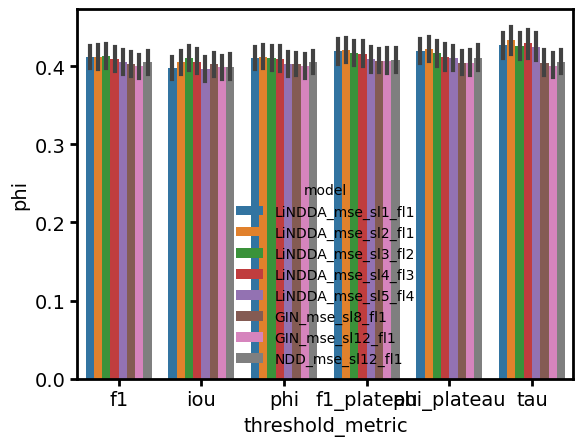

In [63]:
sns.barplot(x[x.model.apply(lambda x: 'GIN' in x or 'NDD' in x)],x='threshold_metric',y='phi',hue='model',estimator=np.mean)

In [64]:
soz_vals = all_val[all_val.model.apply(lambda x: 'GIN' in x or 'NDD' in x)].groupby(['model','patient'],as_index=False).agg({key:'mean' for key in ['nsoz','soz']}).groupby('model',as_index=False).agg({'nsoz':'mean','soz':'mean'})
soz_vals.to_csv(ospj(prodatapath,'baseline_ndd_thresholds.csv'),index=False)

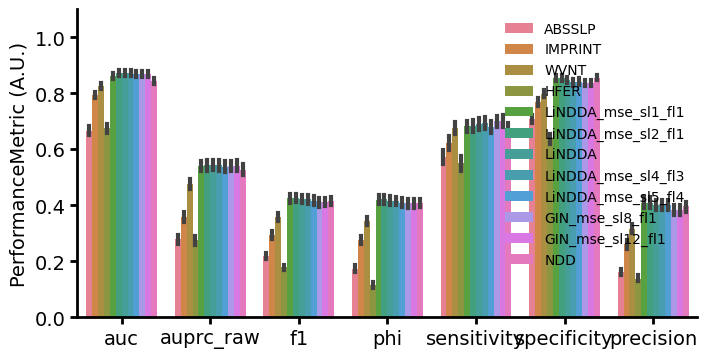

In [65]:
plt.figure(figsize=(8,4))
sns.barplot(x='metric',y='value',hue='model',data=all_val_melted,
estimator=np.mean,
gap=0.0
)
# plt.legend(loc='outside', bbox_to_anchor=(0.25, 1), borderaxespad=0.)
plt.legend()
plt.ylim([0,1.1])
plt.xlabel('')
plt.ylabel('PerformanceMetric (A.U.)')
sns.despine()
plt.show()

In [66]:
# hue_order = ['HFER','ABSSLP','IMPRINT','WVNT','NDD','NDD_tau','LiNDDA','LiNDDA_tau']
# color_palette = ['#377eb8','#4daf4a','#984ea3','#e41a1c','#a65628','#a65628','#ff7f00','#ff7f00',]
hue_order = ['HFER','ABSSLP','IMPRINT','WVNT','NDD','LiNDDA']
color_palette = ['#377eb8','#4daf4a','#984ea3','#e41a1c','#a65628','#ff7f00']

/var/folders/9k/4csk57xn1q1csdw28xvkxm200000gn/T/ipykernel_19291/717829949.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['AUCROC','AUPRC','F1','$\phi$','Sens.','Spec.','Precision'])


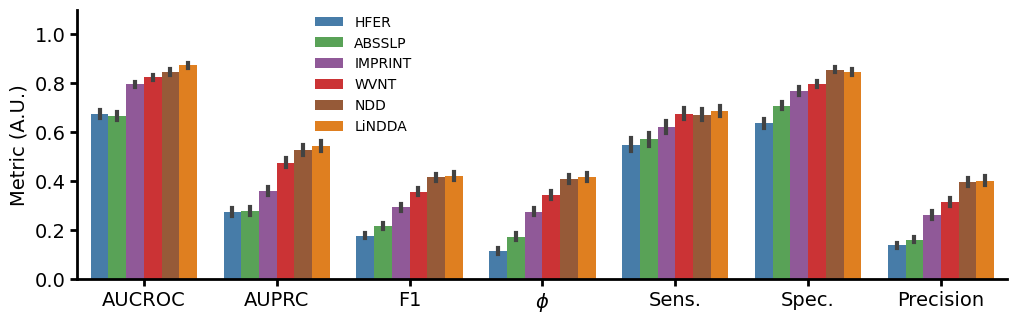

                         auc        f1       phi  sensitivity  specificity  \
model                                                                        
ABSSLP              0.665782  0.218218  0.173681     0.572342     0.707936   
GIN_mse_sl12_fl1    0.867976  0.410700  0.406603     0.699463     0.836312   
GIN_mse_sl8_fl1     0.868023  0.410529  0.406682     0.699317     0.836609   
HFER                0.674587  0.177823  0.116079     0.549666     0.636122   
IMPRINT             0.795175  0.292694  0.274426     0.621381     0.768485   
LiNDDA              0.872843  0.421171  0.416629     0.688460     0.846861   
LiNDDA_mse_sl1_fl1  0.862380  0.424020  0.419505     0.681468     0.855317   
LiNDDA_mse_sl2_fl1  0.870918  0.425748  0.421485     0.684170     0.854620   
LiNDDA_mse_sl4_fl3  0.872355  0.420472  0.415341     0.694449     0.839595   
LiNDDA_mse_sl5_fl4  0.869282  0.415971  0.408996     0.679910     0.841393   
NDD                 0.845193  0.416096  0.408379     0.670732   

In [67]:
fig,ax =   plt.subplots(figsize=(12,3.5))
sns.barplot(x='metric',y='value',hue='model',data=all_val_melted,
estimator=np.mean,
palette=color_palette,
hue_order=hue_order,
gap=0.0
)
# sns.stripplot(x='metric',y='value',hue='model',data=all_val_melted,
# palette = ['grey','grey','grey','grey','grey','grey'],
# size=1,
# alpha=0.2,
# legend=False,
# dodge=True
# )
plt.legend(loc='upper left', bbox_to_anchor=(0.25, 1), borderaxespad=0.)
plt.ylim([0,1.1])
plt.xlabel('')
plt.ylabel('Metric (A.U.)')
ax.set_xticklabels(['AUCROC','AUPRC','F1','$\phi$','Sens.','Spec.','Precision'])
sns.despine()
plt.savefig(ospj(figpath,'validation_performance_metrics.pdf'),bbox_inches='tight',transparent=True)
plt.show()
print(all_val.groupby('model').agg({key:'mean' for key in ['auc','f1','phi','sensitivity','specificity','precision']}))

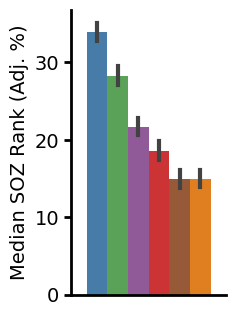

In [68]:
spread_val_melted = pd.melt(all_val, id_vars=['model'], value_vars=['adj_med_soz_spread_rank_pct'], var_name='metric', value_name='value')
plt.figure(figsize=(2,3.7))
sns.barplot(x='metric',y='value',hue='model',data=spread_val_melted,
palette=color_palette,
hue_order=hue_order,
gap=0.0,
legend=False,
estimator=np.mean
)

# plt.legend(bbox_to_anchor=(0.795, 1), loc='upper left', borderaxespad=0.)
plt.xlabel('')
plt.xticks([])
plt.ylabel('Median SOZ Rank (Adj. %)')

sns.despine()
plt.savefig(ospj(figpath,'validation_soz_spread_rank.pdf'),bbox_inches='tight',transparent=True)

In [70]:
import statsmodels.formula.api as smf
all_validation_stats = []
for result_key in ['auc','f1','phi','specificity','precision','recall','sensitivity','avg_soz_recruitment_latency','adj_med_soz_spread_rank_pct']:
    for key1,key2 in zip(['NDD'] * 4 + ['LiNDDA'] * 4,['HFER','ABSSLP','IMPRINT','WVNT']*2):
        # Subset to only LiNDDA and interrater entries, drop rows with missing phi values or patient
        lme_data = all_val[
            all_val['model'].isin([key1, key2])
        ].copy()
        lme_data = lme_data[
            lme_data[result_key].notnull() &
            lme_data['patient'].notnull()
        ]

        # Ensure patient is treated as a categorical
        lme_data['patient'] = lme_data['patient'].astype(str)

        # Pivot to wide form: columns = model_name, values = phi_at_optimal_threshold
        pivot = lme_data.pivot_table(
            index=['patient', 'onset'], 
            columns='model', 
            values=result_key
        ).reset_index()

        # Calculate difference: LiNDDA - interrater for each (patient, onset) pair
        pivot = pivot.dropna(subset=[key1, key2])  # drop pairs lacking either value
        pivot['metric_diff'] = pivot[key1] - pivot[key2]

        # Prepare data for modeling
        diff_data = pivot[['patient', 'metric_diff']].copy()

        # Fit the LME model: phi_diff ~ 1 + (1|patient)
        md = smf.mixedlm(
            "metric_diff ~ 1",
            diff_data,
            groups=diff_data["patient"]
        )
        lme_model = md.fit()
        result_dict = {
            'stage': 'validation',
            'model1': key1,
            'model2': key2,
            'metric': result_key,
            'p_value': lme_model.pvalues['Intercept'],
            'intercept': lme_model.params['Intercept']
        }
        all_validation_stats.append(result_dict)
        # print(key1,', ',key2, lme_model.pvalues['Intercept'])
all_validation_stats = pd.DataFrame(all_validation_stats)
    # print(lme_model.summary())
all_validation_stats.head()

/Users/wojemann/miniforge3/envs/stim-env/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/Users/wojemann/miniforge3/envs/stim-env/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/Users/wojemann/miniforge3/envs/stim-env/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/Users/wojemann/miniforge3/envs/stim-env/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/Users/wojemann/miniforge3/envs/stim-env/lib/python3

,stage,model1,model2,metric,p_value,intercept
0,validation,NDD,HFER,auc,3.468053e-10,0.144486
1,validation,NDD,ABSSLP,auc,5.232419e-18,0.177088
2,validation,NDD,IMPRINT,auc,3.084267e-02,0.026734
3,validation,NDD,WVNT,auc,2.058257e-06,0.021014
4,validation,LiNDDA,HFER,auc,1.252760e-15,0.171409


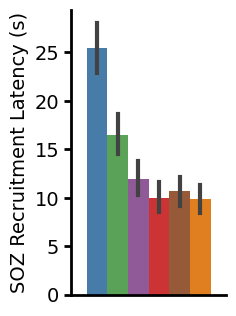

In [54]:
spread_val_melted = pd.melt(all_val, id_vars=['model'], value_vars=['avg_soz_recruitment_latency'], var_name='metric', value_name='value')

plt.figure(figsize=(2,3.7))
sns.barplot(x='metric',y='value',hue='model',data=spread_val_melted,
estimator=np.mean,
palette=color_palette,
hue_order=hue_order,
gap=0.0,
legend=False,
)
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.ylabel('SOZ Recruitment Latency (s)')
plt.xlabel('')
plt.xticks([])
sns.despine()
plt.savefig(ospj(figpath,'validation_soz_recruitment_latency.pdf'),bbox_inches='tight',transparent=True)
plt.show()

In [55]:
# Find the model with the highest average performance for each metric
best_models_per_metric = all_val_melted.groupby(['metric', 'model'])['value'].median().reset_index()
top3_models = best_models_per_metric.groupby('metric').apply(lambda x: x.nlargest(5, 'value')).reset_index(drop=True)
print("Top 3 models for each metric:")
print(top3_models)

Top 3 models for each metric:
         metric               model     value
0           auc              LiNDDA  0.943878
1           auc     GIN_mse_sl8_fl1  0.941327
2           auc  LiNDDA_mse_sl2_fl1  0.941164
3           auc  LiNDDA_mse_sl4_fl3  0.939622
4           auc    GIN_mse_sl12_fl1  0.938776
5     auprc_raw  LiNDDA_mse_sl4_fl3  0.576218
6     auprc_raw              LiNDDA  0.573549
7     auprc_raw  LiNDDA_mse_sl2_fl1  0.566232
8     auprc_raw    GIN_mse_sl12_fl1  0.565617
9     auprc_raw  LiNDDA_mse_sl1_fl1  0.563399
10           f1              LiNDDA  0.444444
11           f1  LiNDDA_mse_sl1_fl1  0.444444
12           f1  LiNDDA_mse_sl2_fl1  0.444444
13           f1  LiNDDA_mse_sl5_fl4  0.439024
14           f1  LiNDDA_mse_sl4_fl3  0.434783
15          phi  LiNDDA_mse_sl2_fl1  0.438854
16          phi              LiNDDA  0.436689
17          phi  LiNDDA_mse_sl1_fl1  0.436304
18          phi  LiNDDA_mse_sl4_fl3  0.435890
19          phi  LiNDDA_mse_sl5_fl4  0.434099
20  

/var/folders/9k/4csk57xn1q1csdw28xvkxm200000gn/T/ipykernel_19291/1676801795.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top3_models = best_models_per_metric.groupby('metric').apply(lambda x: x.nlargest(5, 'value')).reset_index(drop=True)


## Test set performance

In [33]:
# test_data = pd.read_csv(ospj(prodatapath,'test_validation_results.csv'))
# test_data = pd.read_pickle(ospj(prodatapath,'test_validation_results_nopass_nolayernorm.pkl'))
# test_data = pd.read_pickle(ospj(prodatapath,'test_validation_results_ONCET_v1.pkl'))
test_data = pd.read_pickle(ospj(prodatapath,'test_validation_results_v5.pkl'))
# test_data_old = test_data_old[test_data_old.model_name.apply(lambda x: 'GIN' in x or 'LiNDDA' in x)]
# test_data_old['model_name'] = test_data_old['model_name'].map({'GIN':'NDD121','LiNDDA':'LiNDDA11'})
# test_data = pd.concat([test_data,test_data_old],ignore_index=True)
# test_data = test_data[test_data.patient.apply(lambda x: 'HUP' in x)]
test_data = test_data[test_data.stim==0]
test_data = test_data[((test_data.aggregation == 'median') & (test_data.threshold_metric == 'f1_plateau')) | (test_data.aggregation == 'automedian')]
test_data = test_data[test_data.model_key.isin(['LiNDDA_seq3_fc2','NDD_seq12_fc1','ABSSLP','HFER','WVNT','IMPRINT'])]
test_data.loc[(test_data['model_key'] == 'LiNDDA_seq3_fc2') & (test_data['threshold_metric'] == 'tau'),'model_name'] = 'LiNDDA_tau'
test_data.loc[(test_data['model_key'] == 'LiNDDA_seq3_fc2') & (test_data['threshold_metric'] == 'tau'),'onset_phi_at_learned_f1_plateau_median'] = test_data.loc[(test_data['model_key'] == 'LiNDDA_seq3_fc2') & (test_data['threshold_metric'] == 'tau'),'onset_phi_at_learned_tau']
test_data.loc[(test_data['model_key'] == 'LiNDDA_seq3_fc2') & (test_data['threshold_metric'] == 'tau'),'spread_phi_at_learned_f1_plateau_median'] = test_data.loc[(test_data['model_key'] == 'LiNDDA_seq3_fc2') & (test_data['threshold_metric'] == 'tau'),'spread_phi_at_learned_tau']
test_data.loc[(test_data['model_key'] == 'NDD_seq12_fc1') & (test_data['threshold_metric'] == 'tau'),'model_name'] = 'NDD_tau'
test_data.loc[(test_data['model_key'] == 'NDD_seq12_fc1') & (test_data['threshold_metric'] == 'tau'),'onset_phi_at_learned_f1_plateau_median'] = test_data.loc[(test_data['model_key'] == 'NDD_seq12_fc1') & (test_data['threshold_metric'] == 'tau'),'onset_phi_at_learned_tau']
test_data.loc[(test_data['model_key'] == 'NDD_seq12_fc1') & (test_data['threshold_metric'] == 'tau'),'spread_phi_at_learned_f1_plateau_median'] = test_data.loc[(test_data['model_key'] == 'NDD_seq12_fc1') & (test_data['threshold_metric'] == 'tau'),'spread_phi_at_learned_tau']
# test_data['model_name'] = test_data['model_name'].replace('GIN', 'NDD')
# tau_df = test_data[test_data.model_name.isin(['LiNDDA', 'NDD']) & test_data.onset_phi_at_learned_tau.notna()]
# tau_df['onset_phi_at_learned_phi'] = tau_df['onset_phi_at_learned_tau']
# tau_df['region_onset_phi_at_learned_phi'] = tau_df['region_onset_phi_at_learned_tau']
# tau_df['region_spread_phi_at_learned_phi'] = tau_df['region_spread_phi_at_learned_tau']
# tau_df['spread_phi_at_learned_phi'] = tau_df['spread_phi_at_learned_tau']
# tau_df['model_name'] = tau_df['model_name'].apply(lambda x: f"${x}_\\tau$")
# test_data = pd.concat([test_data, tau_df], ignore_index=True)
# hue_order = ['HFER','ABSSLP','IMPRINT','WVNT','NDD','LiNDDA','ONCET','Interrater']

hue_order = ['HFER','ABSSLP','IMPRINT','WVNT','NDD','NDD_tau','LiNDDA','LiNDDA_tau','Interrater']
# color_palette = ['#377eb8','#4daf4a','#984ea3','#e41a1c','#a65628','#ff7f00','gray']
color_palette = ['#377eb8','#4daf4a','#984ea3','#e41a1c','#a65628','#c8885a','#ff7f00','#ffb366','gray']

In [26]:
(~test_data.onset_phi_at_learned_phi_plateau_mean.isna()).sum()

np.int64(0)

### Logistic NDD

In [ ]:
# logistic_results = pd.read_csv(ospj(prodatapath,'ndd_logistic_train_results_all.csv'))
# logistic_results = pd.read_csv(ospj(prodatapath,'ndd_logistic_test_results.csv'))
# logistic_results = logistic_results[logistic_results.patient.apply(lambda x: 'HUP' in x)]

In [ ]:
# key = 'test_phi'
# plt.subplots(figsize=(3.5,4))
# plt.ylabel('$\phi$')
# sns.stripplot(logistic_results,x='model',y=key,hue='model',
# palette=['gray']*7,size=3.5,alpha=0.5,zorder=0,
# dodge = 0
# )

# sns.pointplot(logistic_results,x='model',y=key,hue='model',estimator='mean',
# linestyle='none',
# marker='_',
# markersize=20,
# zorder=1,
# dodge = 0,
# )

### LOPO

In [ ]:
# cval_results = []
# n_patients = test_data.patient.nunique()
# patients = test_data.patient.unique()
# kfold = KFold(n_splits=n_patients-1, shuffle=False)
# tolerance = 0.01  # Tolerance for plateau detection

# for model in test_data.model_name.unique():
#     model_data = test_data[test_data.model_name == model]
#     for train_idx, test_idx in kfold.split(patients):
#         train_patients = patients[train_idx]
#         test_patients = patients[test_idx]
#         data_test = model_data[model_data.patient.isin(test_patients)]
#         data_train = model_data[~model_data.patient.isin(test_patients)]
#         best_thresholds = []
#         best_phis = []
#         for _,group in data_train.groupby('patient'):
#             best_pt_thresholds = []
#             best_pt_phis = []
#             for _,row in group.iterrows():
#                 onset_prob_data = row['onset_prob_data']
#                 X_train = onset_prob_data.loc['probability',:].values
#                 y_train = onset_prob_data.loc['label',:].values
                
#                 # Use linear space of thresholds between 5th and 99th percentiles (100 steps)
#                 min_prob = np.percentile(X_train, 5)
#                 max_prob = np.percentile(X_train, 99)
#                 thresholds = np.linspace(min_prob, max_prob, 100)
                
#                 phi_vals = []
#                 for t in thresholds:
#                     y_pred = (X_train >= t).astype(int)
#                     phi = matthews_corrcoef(y_train, y_pred)
#                     phi_vals.append(phi)
                
#                 phi_vals = np.array(phi_vals)
                
#                 # Find optimal threshold using plateau methodology
#                 if np.any(~np.isnan(phi_vals)):
#                     best_score = np.nanmax(phi_vals)
                    
#                     # Find all thresholds within tolerance of best score
#                     within_tolerance = phi_vals >= (best_score - tolerance)
#                     candidate_indices = np.where(within_tolerance)[0]
                    
#                     if len(candidate_indices) == 0:
#                         # Fallback to best score if no candidates
#                         optimal_idx = np.nanargmax(phi_vals)
#                         best_threshold = thresholds[optimal_idx]
#                         best_phi = phi_vals[optimal_idx]
#                     else:
#                         # Group into continuous segments (plateaus)
#                         segments = []
#                         current_segment = [candidate_indices[0]]
                        
#                         for i in range(1, len(candidate_indices)):
#                             if candidate_indices[i] == candidate_indices[i-1] + 1:
#                                 # Continuous
#                                 current_segment.append(candidate_indices[i])
#                             else:
#                                 # Gap found, start new segment
#                                 segments.append(current_segment)
#                                 current_segment = [candidate_indices[i]]
#                         segments.append(current_segment)  # Add last segment
                        
#                         # Find longest continuous plateau
#                         longest_segment = max(segments, key=len)
                        
#                         # Take midpoint of longest plateau
#                         mid_idx = longest_segment[len(longest_segment) // 2]
#                         best_threshold = thresholds[mid_idx]
#                         best_phi = phi_vals[mid_idx]
#                 else:
#                     best_threshold = np.nan
#                     best_phi = np.nan
                
#                 best_pt_thresholds.append(best_threshold)
#                 best_pt_phis.append(best_phi)
#             best_thresholds.append(np.mean(best_pt_thresholds))
#             best_phis.append(np.mean(best_pt_phis))
#         optimal_threshold = np.mean(best_thresholds)
#         test_phis = []
#         for _,row in data_test.iterrows():
#             onset_prob_data = row['onset_prob_data']
#             X_test = onset_prob_data.loc['probability',:].values
#             y_test = onset_prob_data.loc['label',:].values
#             y_pred = (X_test >= optimal_threshold).astype(int)
#             phi = matthews_corrcoef(y_test,y_pred)
#             test_phis.append(phi)
#             fold_dict = {
#                 'patient':row['patient'],
#                 'onset':row['onset'],
#                 'model':row['model_name'],
#                 'phi':phi,
#                 'train_phi':np.mean(best_phis),
#                 'train_phis':best_phis,
#                 'train_thresholds':best_thresholds,
#                 'train_threshold':optimal_threshold
#             }
#             cval_results.append(fold_dict)
# cval_data = pd.DataFrame(cval_results)
# cval_data.to_csv(ospj(prodatapath,'test_set_cval_results_4.csv'),index=False)
# cval_data = pd.read_csv(ospj(prodatapath,'test_set_cval_results_4.csv'))
# print(cval_data)


### Thresholds

In [18]:
cols = list(test_data.columns)

if 'onset_inter_rater_reliability' not in test_data.columns:
    raise ValueError("No column found for onset_inter_rater_reliability value.")

# Get unique patient/onset pairs and their onset_inter_rater_reliability
unique_pairs = test_data[['patient', 'onset', 'stim','onset_inter_rater_reliability','spread_inter_rater_reliability','region_onset_inter_rater_reliability','region_spread_inter_rater_reliability']].drop_duplicates()

# Create a new DataFrame for interrater results
interrater_rows = []
for _, row in unique_pairs.iterrows():
    new_row = {col: None for col in cols}
    new_row['patient'] = row['patient']
    new_row['onset'] = row['onset']
    new_row['stim'] = row['stim']
    new_row['model_name'] = 'Interrater'
    new_row['full_model_key'] = 'Interrater'
    # Put the onset_inter_rater_reliability into phi_at_optimal_threshold
    new_row['max_onset_phi'] = row['onset_inter_rater_reliability']
    # Assign the reliability value to the desired columns
    for colname in ['onset_phi_at_learned_phi', 'onset_phi_at_learned_f1_plateau_median', 'onset_phi_at_learned_iou', 'onset_phi_at_learned_tau']:
        if colname in cols:
            new_row[colname] = row['onset_inter_rater_reliability']
    for colname in ['max_spread_phi', 'spread_phi_at_learned_phi', 'spread_phi_at_learned_f1_plateau_median', 'spread_phi_at_learned_iou', 'spread_phi_at_learned_tau']:
        if colname in cols:
            new_row[colname] = row['spread_inter_rater_reliability']
    for colname in ['region_max_onset_phi', 'region_max_spread_phi', 'region_onset_phi_at_learned_f1_plateau_median', 'region_onset_phi_at_learned_phi', 'region_spread_phi_at_learned_phi', 'region_onset_auc', 'region_onset_phi_at_learned_tau']:
        if colname in cols:
            new_row[colname] = row['region_onset_inter_rater_reliability']
    for colname in ['region_max_spread_phi', 'region_spread_phi_at_learned_phi', 'region_spread_phi_at_learned_f1_plateau_median', 'region_spread_phi_at_learned_iou', 'region_spread_phi_at_learned_tau']:
        if colname in cols:
            new_row[colname] = row['region_spread_inter_rater_reliability']
    interrater_rows.append(new_row)

interrater_df = pd.DataFrame(interrater_rows, columns=cols)
test_data_interrater = pd.concat([test_data, interrater_df], ignore_index=True)

/var/folders/9k/4csk57xn1q1csdw28xvkxm200000gn/T/ipykernel_19291/515193549.py:36: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  test_data_interrater = pd.concat([test_data, interrater_df], ignore_index=True)


/var/folders/9k/4csk57xn1q1csdw28xvkxm200000gn/T/ipykernel_19291/3085175204.py:23: UserWarning: 
The palette list has fewer values (7) than needed (8) and will cycle, which may produce an uninterpretable plot.
  sns.stripplot(test_data_interrater[test_data_interrater.aggregation == 'median'],x='model_name',y=phi_key,hue='model_name',
/var/folders/9k/4csk57xn1q1csdw28xvkxm200000gn/T/ipykernel_19291/3085175204.py:23: UserWarning: 
The palette list has fewer values (7) than needed (8) and will cycle, which may produce an uninterpretable plot.
  sns.stripplot(test_data_interrater[test_data_interrater.aggregation == 'median'],x='model_name',y=phi_key,hue='model_name',
/var/folders/9k/4csk57xn1q1csdw28xvkxm200000gn/T/ipykernel_19291/3085175204.py:23: UserWarning: 
The palette list has fewer values (7) than needed (8) and will cycle, which may produce an uninterpretable plot.
  sns.stripplot(test_data_interrater[test_data_interrater.aggregation == 'median'],x='model_name',y=phi_key,hue='model

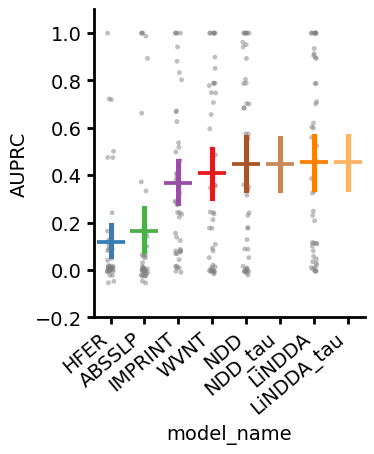

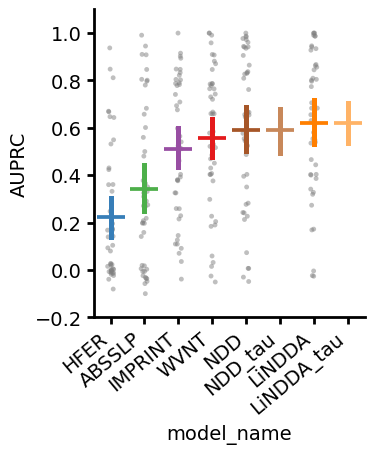

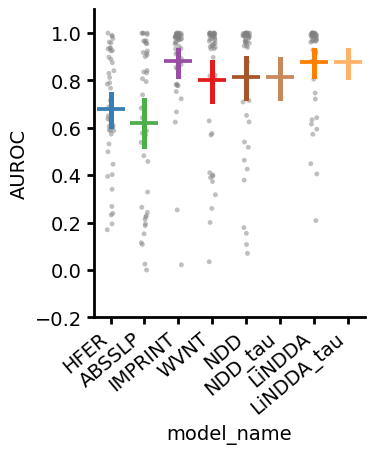

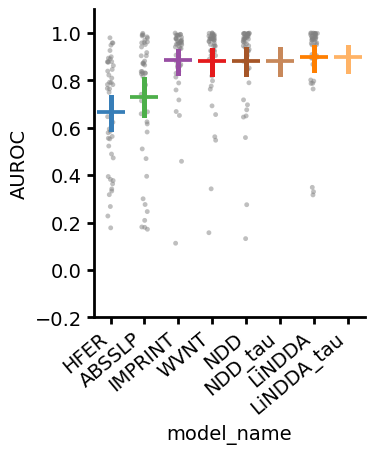

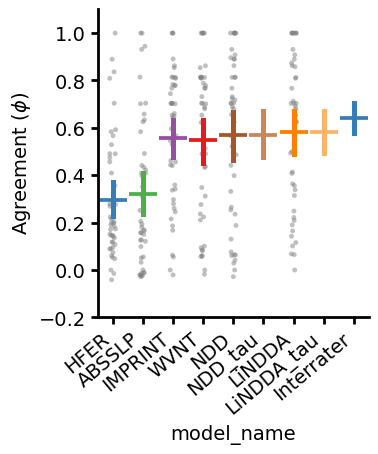

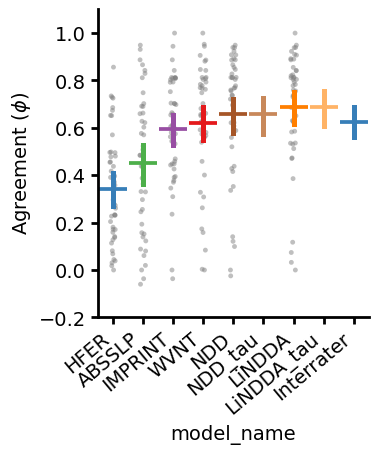

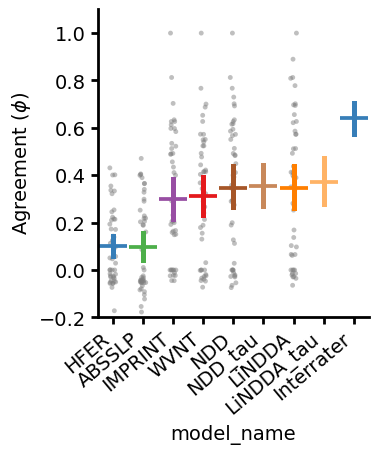

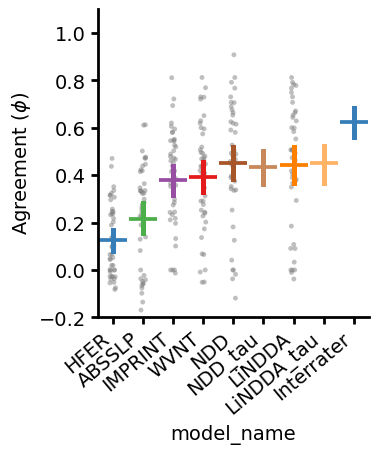

In [19]:
hue_order = ['HFER','ABSSLP','IMPRINT','WVNT','NDD','NDD_tau','LiNDDA','LiNDDA_tau','Interrater']
color_palette = ['#377eb8','#4daf4a','#984ea3','#e41a1c','#a65628','#c8885a','#ff7f00','#ffb366','gray']
for phi_key in ['onset_auprc_normalized','spread_auprc_normalized','onset_auc','spread_auc','max_onset_phi','max_spread_phi','onset_phi_at_learned_f1_plateau_median','spread_phi_at_learned_f1_plateau_median']:

    region = False
    if region:
        phi_key = 'region_'+phi_key

    plt.subplots(figsize=(3.5,4))
    # print(test_data_interrater.groupby('model_name')[phi_key].mean())
    if 'auc' in phi_key:
        plot_hue_order = hue_order.copy()[:-1]
        plot_palette = color_palette.copy()[:-1]
        plt.ylabel('AUROC')
    elif 'auprc' in phi_key:
        plot_hue_order = hue_order.copy()[:-1]
        plot_palette = color_palette.copy()[:-1]
        plt.ylabel('AUPRC')
    else:
        plot_hue_order = hue_order.copy()
        plt.ylabel('Agreement ($\phi$)')

    sns.stripplot(test_data_interrater[test_data_interrater.aggregation == 'median'],x='model_name',y=phi_key,hue='model_name',
    hue_order= plot_hue_order,
    order=plot_hue_order,
    palette=['gray']*7,size=3.5,alpha=0.5,zorder=0,
    dodge = 0
    )

    sns.pointplot(test_data_interrater,x='model_name',y=phi_key,hue='model_name',estimator='mean',
    linestyle='none',
    marker='_',
    markersize=20,
    palette = plot_palette,
    hue_order = plot_hue_order,
    order = plot_hue_order,
    zorder=1,
    dodge = 0
    )

    plt.ylim([0-.2,1.1])
    plt.xticks(rotation=40,ha='right')

    sns.despine()
    plt.legend([])

/var/folders/9k/4csk57xn1q1csdw28xvkxm200000gn/T/ipykernel_19291/447369941.py:25: UserWarning: The palette list has more values (7) than needed (6), which may not be intended.
  sns.stripplot(test_data_interrater[test_data_interrater.aggregation != 'automedian'],x='model_name',y=phi_key,hue='model_name',
/var/folders/9k/4csk57xn1q1csdw28xvkxm200000gn/T/ipykernel_19291/447369941.py:25: UserWarning: The palette list has more values (7) than needed (6), which may not be intended.
  sns.stripplot(test_data_interrater[test_data_interrater.aggregation != 'automedian'],x='model_name',y=phi_key,hue='model_name',
/var/folders/9k/4csk57xn1q1csdw28xvkxm200000gn/T/ipykernel_19291/447369941.py:25: UserWarning: The palette list has more values (7) than needed (6), which may not be intended.
  sns.stripplot(test_data_interrater[test_data_interrater.aggregation != 'automedian'],x='model_name',y=phi_key,hue='model_name',
/var/folders/9k/4csk57xn1q1csdw28xvkxm200000gn/T/ipykernel_19291/447369941.py:25: 

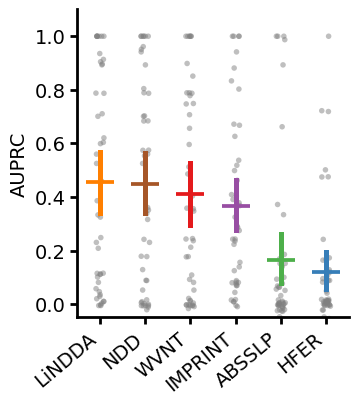

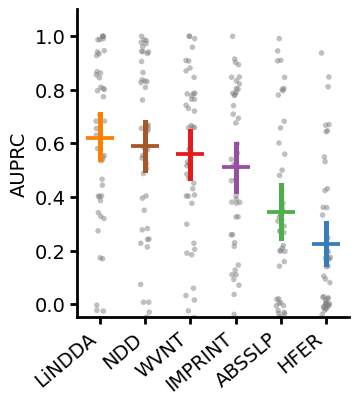

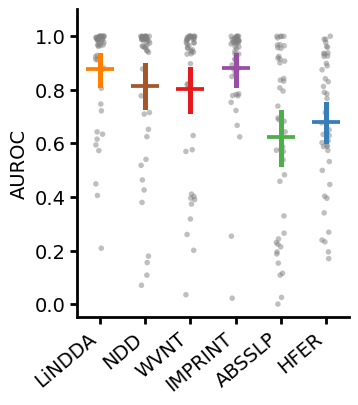

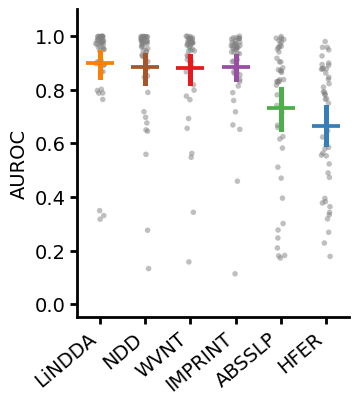

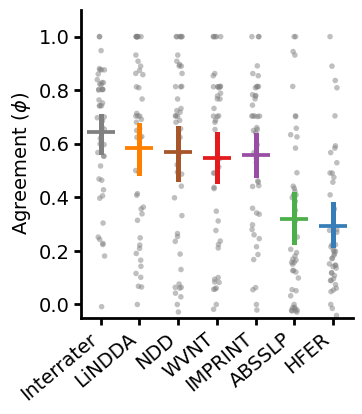

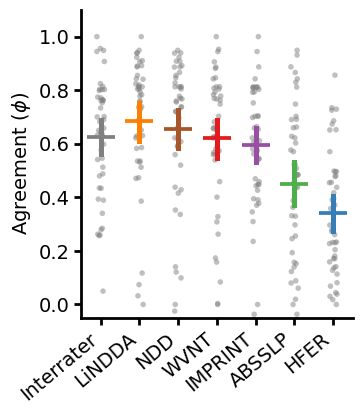

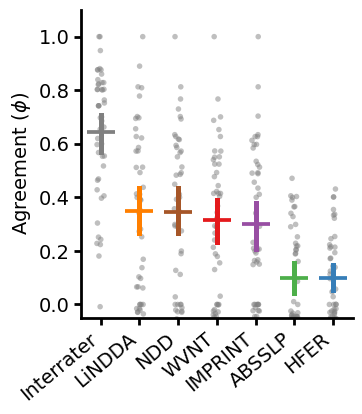

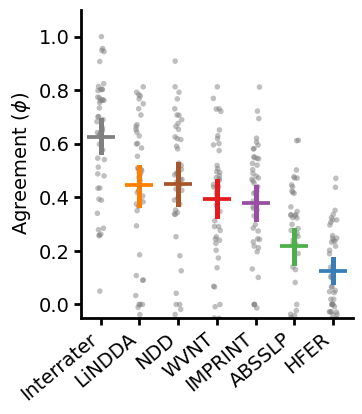

In [20]:
hue_order = ['HFER','ABSSLP','IMPRINT','WVNT','NDD','LiNDDA','Interrater']
# color_palette = ['#377eb8','#4daf4a','#984ea3','#e41a1c','#a65628','#ff7f00','gray']
color_palette = ['#377eb8','#4daf4a','#984ea3','#e41a1c','#a65628','#ff7f00','gray']
for phi_key in ['onset_auprc_normalized','spread_auprc_normalized','onset_auc','spread_auc','max_onset_phi','max_spread_phi','onset_phi_at_learned_f1_plateau_median','spread_phi_at_learned_f1_plateau_median']:

    region = False
    if region:
        phi_key = 'region_'+phi_key

    plt.subplots(figsize=(3.5,4))
    # print(test_data_interrater.groupby('model_name')[phi_key].mean())
    if 'auc' in phi_key:
        plot_hue_order = hue_order.copy()[:-1]
        plot_palette = color_palette.copy()[:-1]
        plt.ylabel('AUROC')
    elif 'auprc' in phi_key:
        plot_hue_order = hue_order.copy()[:-1]
        plot_palette = color_palette.copy()[:-1]
        plt.ylabel('AUPRC')
    else:
        plot_hue_order = hue_order.copy()
        plot_palette = color_palette.copy()
        plt.ylabel('Agreement ($\phi$)')

    sns.stripplot(test_data_interrater[test_data_interrater.aggregation != 'automedian'],x='model_name',y=phi_key,hue='model_name',
    hue_order= plot_hue_order[::-1],
    order=plot_hue_order[::-1],
    palette=['gray']*7,
    size=4,alpha=0.5,zorder=0,
    # palette = plot_palette[::-1],
    dodge = 0
    )

    sns.pointplot(
    # sns.boxplot(
    test_data_interrater,x='model_name',y=phi_key,hue='model_name',
    estimator='mean',
    linestyle='none',
    marker='_',
    markersize=20,
    # fill=False,
    palette = plot_palette[::-1],
    hue_order = plot_hue_order[::-1],
    order = plot_hue_order[::-1],
    zorder=1,
    dodge = 0
    )

    plt.ylim([0-.05,1.1])
    plt.xticks(rotation=40,ha='right')
    plt.xlabel('')
    sns.despine()
    plt.legend([])
    plt.savefig(ospj(figpath,'test_model_agreement_comparison_'+phi_key+'.pdf'),bbox_inches='tight',transparent=True)

In [56]:
phi_keys = ['max_onset_phi','max_spread_phi','onset_phi_at_learned_f1_plateau_median','spread_phi_at_learned_f1_plateau_median']
comparison_df = test_data_interrater.copy()
comparison_df = comparison_df[comparison_df.model_name.isin(['WVNT','IMPRINT','NDD','LiNDDA','NDD_tau','LiNDDA_tau','Interrater'])]
all_dfs = []
for phi_key in phi_keys:
    patient_col = comparison_df['patient']
    onset_col = comparison_df['onset']
    model_col = comparison_df['model_name']
    phase = 'onset' if 'onset' in phi_key else 'spread'
    key_col = model_col + '_' + phi_key
    values = test_data_interrater[phi_key]
    df = pd.DataFrame({'patient':patient_col,'onset':onset_col,'phase':phase,'model':model_col,'key_col':key_col,'phi_key':phi_key,'phi_value':values})
    all_dfs.append(df)
# Use ignore_index=True to avoid duplicate index labels that cause reindexing errors
plot_df = pd.concat(all_dfs,axis=0, ignore_index=True).dropna(how='any')

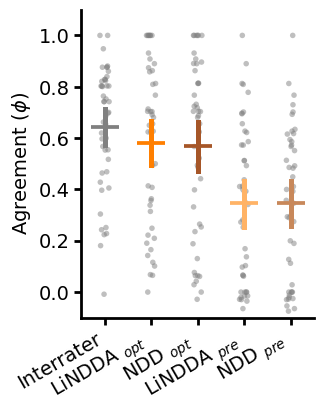

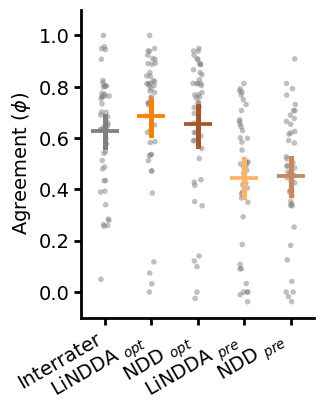

In [57]:
# comp_palette = ['gray','#ff7f00','#a65628','#ffb366','#c8885a','#ffd9a8','#e5c4a8']

comp_palette = ['gray','#ff7f00','#a65628','#ffb366','#c8885a',]
for phase in ['onset','spread']:

    comp_hue_order = [f'Interrater_max_{phase}_phi',
    f'LiNDDA_max_{phase}_phi',f'NDD_max_{phase}_phi',
    # f'WVNT_max_{phase}_phi',f'IMPRINT_max_{phase}_phi',
    # f'NDD_tau_{phase}_phi_at_learned_f1_plateau_median',f'LiNDDA_tau_{phase}_phi_at_learned_f1_plateau_median',
    f'LiNDDA_{phase}_phi_at_learned_f1_plateau_median',f'NDD_{phase}_phi_at_learned_f1_plateau_median',
    # f'WVNT_{phase}_phi_at_learned_f1_plateau_median',f'IMPRINT_{phase}_phi_at_learned_f1_plateau_median',
    ]

    # Filter plot_df to only include keys in comp_hue_order to avoid reindexing errors
    plot_df_filtered = plot_df[plot_df['key_col'].isin(comp_hue_order)].copy()
    fig,ax = plt.subplots(figsize=(3,4))
    sns.stripplot(plot_df_filtered,x='key_col',y='phi_value',hue='key_col',
    hue_order=comp_hue_order,
    order=comp_hue_order,
    palette=['gray']*len(comp_hue_order),
    size=4,alpha=0.5,zorder=0,
    dodge = 0
    )

    sns.pointplot(plot_df_filtered,x='key_col',y='phi_value',hue='key_col',estimator='mean',
    linestyle='none',
    marker='_',
    markersize=20,
    palette = comp_palette,
    hue_order = comp_hue_order,
    order = comp_hue_order,
    zorder=1,
    dodge = 0
    )

    plt.ylim([0-.1,1.1])
    plt.xticks(np.arange(len(comp_hue_order)),[
    'Interrater','LiNDDA $_{opt}$','NDD $_{opt}$',
    # 'WVNT $_{opt}$','IMPRINT $_{opt}$',
    'LiNDDA $_{pre}$','NDD $_{pre}$',
    # 'WVNT $_{pre}$','IMPRINT $_{pre}$'
    ],rotation=30,ha='right')
    plt.ylabel('Agreement ($\phi$)')
    plt.xlabel('')
    sns.despine()
    plt.legend([])
    plt.savefig(ospj(figpath,'test_model_agreement_comparison_'+phase+'.pdf'),bbox_inches='tight',transparent=True)

In [58]:
test_data_interrater[test_data_interrater.model_name.isin(['Interrater']) & ~test_data_interrater.max_onset_phi.isna()]['max_onset_phi'].values

array([ 0.74191458,  0.74191458,  0.74191458,  0.59977886,  0.39685601,
        0.80333277,  0.55437447,  0.46865252,  1.        ,  0.80252986,
        1.        ,  0.76352569,  0.61982638,  0.82096235,  0.88064157,
        0.75234825,  0.86029651,  0.70016335,  0.42810386,  0.46386455,
        0.18085486,  0.87611579,  0.22793334,  0.87604194,  0.87604194,
        0.24288289,  0.82350557,  0.68537998,  0.83940835,  0.56729762,
        0.55324545,  0.65430352,  0.80065635,  0.94792586,  0.80281766,
        0.59703409,  0.80266574,  0.40552961,  0.30399694,  0.82844774,
        0.82844774,  0.69722519,  0.66243817,  0.25143095,  0.22372684,
       -0.00834348,  0.51711771])

In [73]:
test_data_interrater.columns.to_list()

['patient',
 'onset',
 'stim',
 'model_name',
 'model_key',
 'full_model_key',
 'sequence_length',
 'forecast_length',
 'metric',
 'onset_inter_rater_reliability',
 'spread_inter_rater_reliability',
 'onset_prob_data',
 'spread_prob_data',
 'threshold_metric',
 'aggregation',
 'threshold',
 'optimal_onset_threshold',
 'max_onset_phi',
 'onset_phi_annotators_at_optimal',
 'optimal_spread_threshold',
 'max_spread_phi',
 'spread_phi_annotators_at_optimal',
 'avg_onset_soz_prob',
 'avg_onset_nsoz_prob',
 'onset_auc',
 'onset_auprc_raw',
 'onset_auprc_normalized',
 'avg_spread_soz_prob',
 'avg_spread_nsoz_prob',
 'spread_auc',
 'spread_auprc_raw',
 'spread_auprc_normalized',
 'region_onset_inter_rater_reliability',
 'region_spread_inter_rater_reliability',
 'region_avg_onset_soz_prob',
 'region_avg_onset_nsoz_prob',
 'region_onset_auc',
 'region_onset_auprc_raw',
 'region_onset_auprc_normalized',
 'region_avg_spread_soz_prob',
 'region_avg_spread_nsoz_prob',
 'region_spread_auc',
 'region_s

In [77]:
result_keys = ['onset_auprc_normalized','spread_auprc_normalized','onset_auc','spread_auc','max_onset_phi','max_spread_phi','onset_phi_at_learned_f1_plateau_median','spread_phi_at_learned_f1_plateau_median']
result_keys += ['region_'+key for key in result_keys]
all_test_stats = []
for result_key in result_keys:
    for key1,key2 in zip(['NDD'] * 5 + ['LiNDDA'] * 5,['HFER','ABSSLP','IMPRINT','WVNT','Interrater']*2):
        if "au" in result_key and key2 == 'Interrater':
            continue
        # Subset to only LiNDDA and interrater entries, drop rows with missing phi values or patient
        lme_data = test_data_interrater[
            test_data_interrater['model_name'].isin([key1, key2])
        ].copy()
        lme_data = lme_data[
            lme_data[result_key].notnull() &
            lme_data['patient'].notnull()
        ]

        # Ensure patient is treated as a categorical
        lme_data['patient'] = lme_data['patient'].astype(str)

        # Drop duplicates to avoid reindexing errors on duplicate labels
        # Keep first occurrence if there are duplicate patient/onset/model_name combinations
        lme_data = lme_data.drop_duplicates(subset=['patient', 'onset', 'model_name'], keep='first')

        # Pivot to wide form: columns = model_name, values = phi_at_optimal_threshold
        pivot = lme_data.pivot_table(
            index=['patient', 'onset'], 
            columns='model_name', 
            values=result_key,
            aggfunc='first'  # Handle any remaining duplicates as a safeguard
        ).reset_index()

        # Calculate difference: LiNDDA - interrater for each (patient, onset) pair
        pivot = pivot.dropna(subset=[key1, key2])  # drop pairs lacking either value
        pivot['metric_diff'] = pivot[key1] - pivot[key2]

        # Prepare data for modeling
        diff_data = pivot[['patient', 'metric_diff']].copy()

        # Fit the LME model: phi_diff ~ 1 + (1|patient)
        md = smf.mixedlm(
            "metric_diff ~ 1",
            diff_data,
            groups=diff_data["patient"]
        )
        lme_model = md.fit()
        result_dict = {
            'stage': 'test',
            'model1': key1,
            'model2': key2,
            'metric': result_key,
            'p_value': lme_model.pvalues['Intercept'],
            'intercept': lme_model.params['Intercept']
        }
        all_test_stats.append(result_dict)
        # print(key1,', ',key2, lme_model.pvalues['Intercept'])
all_test_stats = pd.DataFrame(all_test_stats)
all_stats = pd.concat([all_validation_stats,all_test_stats])
from statsmodels.stats.multitest import multipletests

# Add p-rank column (ranking p-values within each metric+stage group)
all_stats['p_rank'] = all_stats.groupby(['metric', 'stage'])['p_value'].rank(method='average', ascending=True)

# FDR-correct p-values within each metric+stage group
def fdr_within_group(df):
    _, pvals_fdr, _, _ = multipletests(df['p_value'].values, alpha=0.05, method='fdr_bh')
    df = df.copy()
    df['p_fdr_corrected'] = pvals_fdr
    return df

all_stats = all_stats.groupby(['metric', 'stage'], group_keys=False).apply(fdr_within_group)
all_stats = all_stats.sort_values(['stage','metric','model1','model2'])
all_stats.to_csv(ospj(prodatapath,'model_performance_stats.csv'),index=False)
    # print(lme_model.summary())

/Users/wojemann/miniforge3/envs/stim-env/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/Users/wojemann/miniforge3/envs/stim-env/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/Users/wojemann/miniforge3/envs/stim-env/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/Users/wojemann/miniforge3/envs/stim-env/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/Users/wojemann/miniforge3/envs/stim-env/lib/python3

In [ ]:
# import statsmodels.formula.api as smf
# for key1,key2 in zip(['NDD'] * 5 + ['WVNT'] * 5,['HFER','ABSSLP','IMPRINT','LiNDDA','Interrater']*2):
#     # Subset to only LiNDDA and interrater entries, drop rows with missing phi values or patient
#     lme_data = test_data_interrater[
#         test_data_interrater['model_name'].isin([key1, key2])
#     ].copy()
#     lme_data = lme_data[
#         lme_data[phi_key].notnull() &
#         lme_data['patient'].notnull()
#     ]

#     # Ensure patient is treated as a categorical
#     lme_data['patient'] = lme_data['patient'].astype(str)

#     # Pivot to wide form: columns = model_name, values = phi_at_optimal_threshold
#     pivot = lme_data.pivot_table(
#         index=['patient', 'onset'], 
#         columns='model_name', 
#         values=phi_key
#     ).reset_index()

#     # Calculate difference: LiNDDA - interrater for each (patient, onset) pair
#     pivot = pivot.dropna(subset=[key1, key2])  # drop pairs lacking either value
#     pivot['phi_diff'] = pivot[key1] - pivot[key2]

#     # Prepare data for modeling
#     diff_data = pivot[['patient', 'phi_diff']].copy()

#     # Fit the LME model: phi_diff ~ 1 + (1|patient)
#     md = smf.mixedlm(
#         "phi_diff ~ 1",
#         diff_data,
#         groups=diff_data["patient"]
#     )
#     lme_model = md.fit()
#     print(key1,', ',key2, lme_model.pvalues['Intercept'])
#     # print(lme_model.summary())

0.8528395061728393


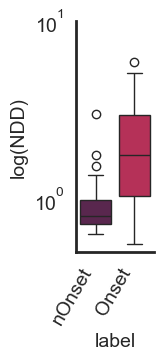

In [ ]:
all_nsoz = []
all_soz = []
# 'LiNDDA_mse_sl1_fl1'
# 'GIN_mse_sl12_fl1'
for _,group in test_data_interrater[test_data_interrater.full_model_key.isin(['LiNDDA_mse_sl3_fl2']) & (test_data_interrater.aggregation == 'median')].groupby(['patient']):
    all_nsoz.append(group.avg_onset_nsoz_prob.mean())
    all_soz.append(group.avg_onset_soz_prob.mean())
all_nsoz = np.array(all_nsoz)
all_soz = np.array(all_soz)
all_nsoz = test_data_interrater[test_data_interrater.full_model_key.isin(['LiNDDA_mse_sl3_fl2']) & (test_data_interrater.aggregation == 'median')].avg_onset_nsoz_prob.values
all_soz = test_data_interrater[test_data_interrater.full_model_key.isin(['LiNDDA_mse_sl3_fl2']) & (test_data_interrater.aggregation == 'median')].avg_onset_soz_prob.values
annot_dataset = pd.concat([pd.DataFrame(np.concatenate((all_nsoz,all_soz),axis=0),columns=['probability']),pd.DataFrame(['nsoz']*len(all_nsoz) + ['soz']*len(all_soz),columns=['label'])],axis=1).dropna()
plt.figure(figsize=(1,3))
plt.xticks([0,1],['nOnset','Onset'],rotation=60,ha='right')
sns.boxplot(annot_dataset,x='label',y='probability',hue='label',palette=sns.color_palette('rocket',n_colors=3)[:2],width=.8,legend=False)
plt.ylabel('log(NDD)')
plt.yscale('log')
plt.ylim([0.5,10])
sns.despine()
print(roc_auc_score(annot_dataset.label,annot_dataset.probability))
plt.savefig(ospj(figpath,'onset_localization.pdf'),bbox_inches='tight',transparent=True)

0.9032098765432098


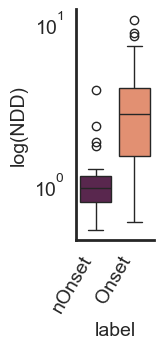

In [ ]:
all_nsoz = []
all_soz = []
# 'LiNDDA_mse_sl1_fl1'
# 'GIN_mse_sl12_fl1'
for _,group in test_data_interrater[test_data_interrater.full_model_key.isin(['LiNDDA_mse_sl3_fl2'])].groupby('patient'):
    all_nsoz.append(group.avg_spread_nsoz_prob.mean())
    all_soz.append(group.avg_spread_soz_prob.mean())
all_nsoz = np.array(all_nsoz)
all_soz = np.array(all_soz)
all_nsoz = test_data_interrater[test_data_interrater.full_model_key.isin(['LiNDDA_mse_sl3_fl2']) & (test_data_interrater.aggregation == 'median')].avg_spread_nsoz_prob.values
all_soz = test_data_interrater[test_data_interrater.full_model_key.isin(['LiNDDA_mse_sl3_fl2']) & (test_data_interrater.aggregation == 'median')].avg_spread_soz_prob.values
annot_dataset = pd.concat([pd.DataFrame(np.concatenate((all_nsoz,all_soz),axis=0),columns=['probability']),pd.DataFrame(['nsoz']*len(all_nsoz) + ['soz']*len(all_soz),columns=['label'])],axis=1).dropna()
plt.figure(figsize=(1,3))
plt.xticks([0,1],['nOnset','Onset'],rotation=60,ha='right')
sns.boxplot(annot_dataset,x='label',y='probability',hue='label',palette=sns.color_palette('rocket',n_colors=3)[::2],width=.8,legend=False)
plt.ylabel('log(NDD)')
plt.yscale('log')
# plt.ylim([0.5,10])
sns.despine()
print(roc_auc_score(annot_dataset.label,annot_dataset.probability))
plt.savefig(ospj(figpath,'spread_localization.pdf'),bbox_inches='tight',transparent=True)

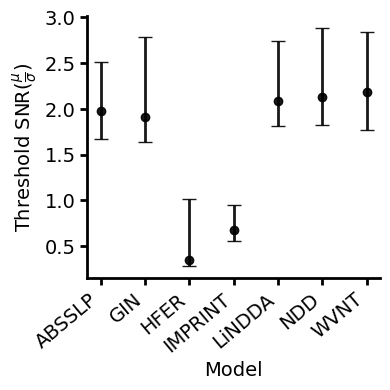

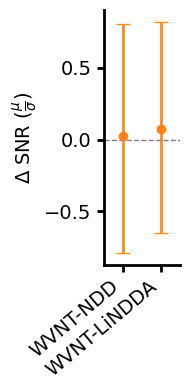

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Restrict to just test_data (not the interrater-augmented DataFrame)
snr_results = []
n_boot = 1000
rng = np.random.default_rng(42)

for model in test_data['model_name'].unique():
    vals = test_data.loc[
        test_data['model_name'] == model, 'optimal_onset_threshold' if 'optimal_onset_threshold' in test_data.columns else 'phi_at_optimal_threshold'
    ].dropna().values
    if len(vals) < 2:
        continue
    mean = np.nanmean(vals)
    std = np.nanstd(vals, ddof=1)
    if std == 0:
        continue
    snr = mean / std

    # Bootstrap CIs
    snr_boots = []
    for _ in range(n_boot):
        boot = rng.choice(vals, size=len(vals), replace=True)
        boot_mean = np.nanmean(boot)
        boot_std = np.nanstd(boot, ddof=1)
        if boot_std > 0:
            snr_boots.append(boot_mean / boot_std)
    if not snr_boots:
        continue
    ci_lower, ci_upper = np.percentile(snr_boots, [2.5, 97.5])

    snr_results.append({
        'model': model,
        'snr': snr,
        'ci_lower': ci_lower,
        'ci_upper': ci_upper,
        'n': len(vals)
    })

snr_df = pd.DataFrame(snr_results)
snr_df = snr_df.sort_values('model')

fig, ax = plt.subplots(figsize=(4, 4))
xvals = np.arange(len(snr_df))
ax.errorbar(
    xvals,
    snr_df['snr'],
    yerr=[snr_df['snr'] - snr_df['ci_lower'], snr_df['ci_upper'] - snr_df['snr']],
    fmt='o',
    capsize=5,
    color='black',
    alpha=0.9,
)
ax.set_xticks(xvals)
ax.set_xticklabels(snr_df['model'], rotation=40, ha='right')
ax.set_xlabel('Model')
ax.set_ylabel('Threshold SNR($\\frac{\mu}{\sigma}$)')
plt.tight_layout()
sns.despine()
plt.savefig(ospj(figpath,'threshold_snr.pdf'),bbox_inches='tight',transparent=True)
plt.show()
# WVNT - NDD and WVNT - LiNDDA SNR median difference bootstrap with CIs

models = snr_df['model'].tolist()
if 'WVNT' in models and 'NDD' in models and 'LiNDDA' in models:
    # For proper bootstrap, get the underlying vals for each model from test_data
    snr_boots_dict = {}
    for model in ['WVNT', 'NDD', 'LiNDDA']:
        vals = test_data.loc[test_data['model_name'] == model, ['optimal_onset_threshold', 'max_onset_phi']].dropna()['optimal_onset_threshold'].values
        if len(vals) < 2:
            snr_boots_dict[model] = []
            continue
        boots = []
        for _ in range(10000):
            boot = rng.choice(vals, size=len(vals), replace=True)
            boot_mean = np.nanmean(boot)
            boot_std = np.nanstd(boot, ddof=1)
            if boot_std > 0:
                boots.append(boot_mean / boot_std)
        snr_boots_dict[model] = np.array(boots)

    # Calculate differences
    diff_WVNT_NDD = snr_boots_dict['WVNT'] - snr_boots_dict['NDD']
    diff_WVNT_LiNDDA = snr_boots_dict['WVNT'] - snr_boots_dict['LiNDDA']

    # Get medians and bootstrap CIs
    median_diff_WVNT_NDD = np.median(diff_WVNT_NDD)
    ci_WN = np.percentile(diff_WVNT_NDD, [2.5, 97.5])
    median_diff_WVNT_LiNDDA = np.median(diff_WVNT_LiNDDA)
    ci_WL = np.percentile(diff_WVNT_LiNDDA, [2.5, 97.5])

    fig, ax = plt.subplots(figsize=(2, 4))
    diff_medians = [median_diff_WVNT_NDD, median_diff_WVNT_LiNDDA]
    err_lower = [median_diff_WVNT_NDD - ci_WN[0], median_diff_WVNT_LiNDDA - ci_WL[0]]
    err_upper = [ci_WN[1] - median_diff_WVNT_NDD, ci_WL[1] - median_diff_WVNT_LiNDDA]
    ax.errorbar(
        ['WVNT-NDD', 'WVNT-LiNDDA'],
        diff_medians,
        yerr=[err_lower, err_upper],
        fmt='o',
        capsize=5,
        color='C1',
        alpha=0.9,
    )
    plt.xlim([-0.5,1.5])
    plt.xticks([0,1],['WVNT-NDD', 'WVNT-LiNDDA'],rotation=40,ha='right')
    ax.axhline(0, ls='--', c='gray', lw=1)
    ax.set_ylabel('$\Delta$ SNR ($\\frac{\mu}{\sigma}$)')
    plt.tight_layout()
    sns.despine()
    plt.savefig(ospj(figpath,'threshold_snr_diff.pdf'),bbox_inches='tight',transparent=True)
    plt.show()

## Visualization

In [ ]:
onset_annots = pd.read_pickle(ospj(prodatapath,'threshold_tuning_consensus_v2.pkl'))
onset_annots = onset_annots[onset_annots.stim == 0]
onset_annots['ueo_channels'] = onset_annots.apply(lambda x: np.array(x.all_chs)[x.ueo_consensus],axis=1)

In [ ]:
onset_annots[onset_annots.patient == 'HUP225']

,Seizure_ID,clinician,patient,ueo,ueo_time,sec,all_chs,iEEG_ID,approximate_onset,offset,stim,ueo_consensus,ueo_any,ueo_time_consensus,sec_consensus,sec_any,ueo_channels
29,HUP225_2,"[EC, JJ, JK]",HUP225,"[[False, False, False, False, False, False, Fa...","[393498.33, 304944.5422, 304959.37]","[[False, False, False, False, False, False, Fa...","[ECG01, ECG02, Fp01, RA01, RA02, RA03, RA04, R...",HUP225_phaseII,304944.5422,305031.85,0.0,"[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal...",304959.37,"[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal...","[RT04, RT05]"
30,HUP225_3,"[EC, JJ, JK]",HUP225,"[[False, False, False, False, False, False, Fa...","[408576.51, 393499.84, 393498.17]","[[False, False, False, False, False, False, Fa...","[ECG01, ECG02, Fp01, RA01, RA02, RA03, RA04, R...",HUP225_phaseII,393496.2000,393587.96,0.0,"[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal...",393499.84,"[False, False, False, False, False, False, Fal...","[False, False, False, False, False, True, Fals...",[RT05]
31,HUP225_4,"[JJ, JK]",HUP225,"[[False, False, False, False, False, False, Fa...","[408575.99, 408576.51]","[[False, False, False, False, False, False, Fa...","[ECG01, ECG02, Fp01, RA01, RA02, RA03, RA04, R...",HUP225_phaseII,408565.8100,408670.81,0.0,"[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal...",408576.25,"[False, False, False, False, False, True, True...","[False, False, False, False, False, True, True...","[RT04, RT05]"


In [ ]:
# test_mat = pd.read_pickle(ospj(prodatapath,'sz_prob/HUP224/HUP224_task-ictal339143_run-00_mdl-ABSSLP_sz_prob.pkl'))

# test_mat = pd.read_pickle(ospj(prodatapath,'sz_prob/HUP238/HUP238_task-ictal290006_run-00_mdl-ONCET_sz_prob.pkl'))

test_mat = pd.read_pickle(ospj(prodatapath,'sz_prob/HUP225/HUP225_task-ictal393496_run-00_mdl-ONCET_sz_prob.pkl'))

# test_mat = pd.read_pickle('/Users/wojemann/local_data/dynasd_data/PROCESSED_DATA/sz_prob/HUP238/HUP238_task-ictal290006_mdl-LiNDDA_seq-5_mse_prob_forecast-4.pkl')
prob_times = test_mat.pop('time')
onset_idx = np.argmin(np.abs(prob_times-180))
sz_onset_annot = onset_annots.loc[(onset_annots.patient == 'HUP225') & ((onset_annots.approximate_onset - 304819) < 240)]
onset_chs =np.array([ch[0] in sz_onset_annot.ueo_channels.iloc[0] for ch in test_mat.columns.str.split('-')])
# test_mat /= 100

In [ ]:
# print(onset_idx)
# test_mat.loc[310:365,['LC01-LC02']]

In [ ]:
thresh = 0.95
# 1.293061534
test_mat.columns[np.argwhere((test_mat.loc[360:365,:]>thresh).sum()>4)[:,0]]
test_mat.columns[np.argwhere((test_mat.loc[360:365,:].median()>thresh))[:,0]]

Index(['RA01-RA02', 'ROf05-ROf06', 'RU01-RU02', 'RZ05-RZ06'], dtype='object')

In [ ]:
# plt.plot(test_mat.loc[300:420,test_mat.columns[np.argwhere((test_mat.loc[360:365,:].median()>1.163061534))[:,0]].to_list()])
# plt.legend(test_mat.columns[np.argwhere((test_mat.loc[360:365,:].median()>1.163061534))[:,0]].to_list()+['LC01-LC02'])

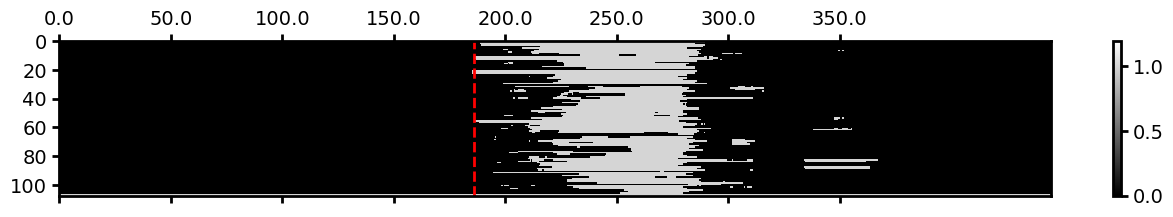

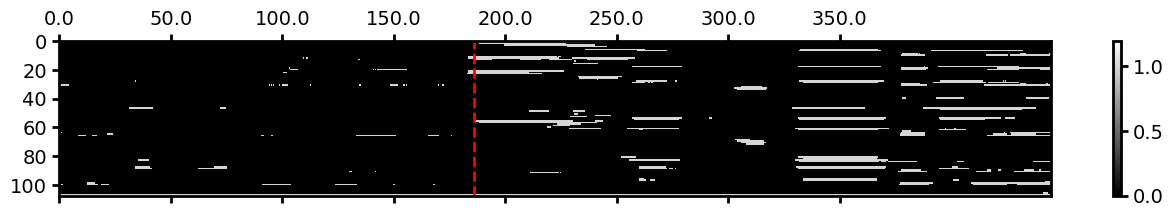

In [ ]:
for test_mat in [pd.read_pickle(ospj(prodatapath,'sz_prob/HUP238/HUP238_task-ictal290006_run-00_mdl-WVNT_sz_prob.pkl')),
pd.read_pickle(ospj(prodatapath,'sz_prob/HUP238/HUP238_task-ictal290006_run-00_mdl-ONCET_sz_prob.pkl'))]:
    plt.matshow(sc.ndimage.uniform_filter1d(test_mat.T,20,axis=1)>0.9,aspect='auto',cmap='gray',
    clim=(0,1.2)
    )

    plt.xticks(ticks=np.arange(0, len(prob_times), 100), labels=prob_times.to_numpy()[::100].round(0))
    onset_idx = np.argmin(np.abs(prob_times-186))
    plt.axvline(onset_idx,linestyle='--',color='red')
    plt.colorbar()
    plt.show()

## Probing NDD

In [ ]:
# Get the project root (parent directory of examples/)
# script_dir = os.path.dirname(os.path.abspath(__file__))
script_dir = '/Users/wojemann/Documents/CNT/stim-seizures/code'
dynasd_root = os.path.join(script_dir, '..', '..', 'DynaSD')

if dynasd_root not in sys.path:
    sys.path.insert(0, dynasd_root)

from DynaSD import NDD as DYNDD
from DynaSD import LiNDDA, MINDD, GIN

dsosd_root = os.path.join(script_dir, '..', '..', 'DSOSD')
if dsosd_root not in sys.path:
    sys.path.insert(0, dsosd_root)

from DSOSD.model import NDD as DSNDD
from utils import plot_iEEG_data

## SZ detect plotting

In [ ]:
example_seizure = pd.read_pickle('/Users/wojemann/Documents/CNT/stim_seizures_data/PROCESSED_DATA/plot_sz_238.pkl')

In [ ]:
example_seizure.columns

Index(['LA01-LA02', 'LA02-LA03', 'LA03-LA04', 'LA04-LA05', 'LA05-LA06',
       'LA06-LA07', 'LB01-LB02', 'LB02-LB03', 'LB03-LB04', 'LB04-LB05',
       'LB05-LB06', 'LB06-LB07', 'LB07-LB08', 'LC01-LC02', 'LC02-LC03',
       'LC03-LC04', 'LC04-LC05', 'LC05-LC06', 'LC06-LC07', 'LC07-LC08',
       'LE01-LE02', 'LE02-LE03', 'LE03-LE04', 'LE04-LE05', 'LE05-LE06',
       'LE06-LE07', 'LF01-LF02', 'LF02-LF03', 'LF03-LF04', 'LF04-LF05',
       'LF05-LF06', 'LF06-LF07', 'LG01-LG02', 'LG02-LG03', 'LG03-LG04',
       'LG04-LG05', 'LG05-LG06', 'LI01-LI02', 'LI02-LI03', 'LI03-LI04',
       'LI04-LI05', 'LI05-LI06', 'LO01-LO02', 'LO02-LO03', 'LO03-LO04',
       'LO04-LO05', 'LO05-LO06', 'LO06-LO07', 'LO07-LO08', 'LO08-LO09',
       'LQ01-LQ02', 'LQ02-LQ03', 'LQ03-LQ04', 'LQ04-LQ05', 'LQ05-LQ06',
       'LT03-LT04', 'LU01-LU02', 'LU02-LU03', 'LU03-LU04', 'LU04-LU05',
       'LY01-LY02', 'LY02-LY03', 'LY03-LY04', 'LY04-LY05', 'LY05-LY06',
       'LY06-LY07', 'LY07-LY08', 'LY10-LY11', 'LY11-LY12'],
    

In [ ]:
plot_ch = ['LE01-LE02', 'LE02-LE03', 'LE03-LE04', 'LE04-LE05', 'LE05-LE06',
       'LE06-LE07', 'LF01-LF02', 'LF02-LF03', 'LF03-LF04', 'LF04-LF05',
       'LF05-LF06', 'LF06-LF07', 'LI01-LI02', 'LI02-LI03', 'LI03-LI04',
       'LI04-LI05', 'LI05-LI06', 'LO01-LO02', 'LO02-LO03', 'LO03-LO04',
       'LO04-LO05', 'LO05-LO06', 'LO06-LO07', 'LO07-LO08', 'LO08-LO09']

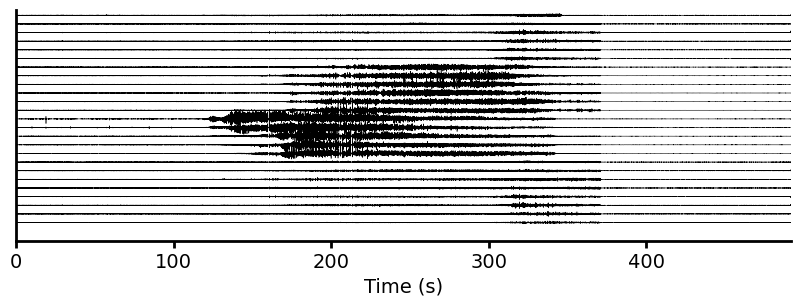

In [ ]:
plot_iEEG_data(example_seizure[plot_ch],128,fig_size = (10,3))
plt.yticks([])
plt.savefig(ospj(figpath,'sz_detect_example_seizure.pdf'),bbox_inches='tight',transparent=True)
plt.show()

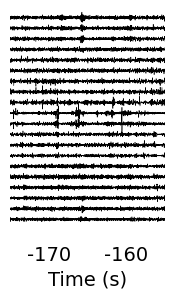

In [ ]:
annot_plot_ch = [ 'LE05-LE06',
        'LF01-LF02', 'LF04-LF05',
       'LF05-LF06', 'LF06-LF07', 'LI01-LI02', 'LI02-LI03', 'LI03-LI04',
       'LI04-LI05', 'LO01-LO02', 'LO02-LO03', 'LO03-LO04',
       'LO04-LO05', 'LO05-LO06', 'LO08-LO09']
plot_iEEG_data(example_seizure.loc[20*128:40*128,plot_ch],128,empty=True,fig_size = (2,3))
plt.yticks([])
plt.xticks([5,15],[-170,-160])
plt.savefig(ospj(figpath,'sz_detect_example_baseline.pdf'),bbox_inches='tight',transparent=True)
plt.show()

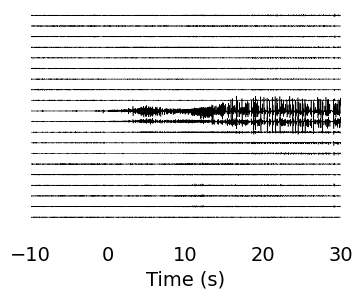

In [ ]:
plot_iEEG_data(example_seizure.loc[110*128:150*128,plot_ch],128,empty=True,fig_size = (4,3),t_offset = -10)
plt.yticks([])
plt.savefig(ospj(figpath,'sz_detect_example_sz.pdf'),bbox_inches='tight',transparent=True)
plt.show()

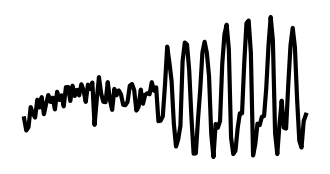

In [ ]:
fig,ax = plt.subplots(figsize = (4,2))
ax.plot(example_seizure.loc[119.5*128:120.5*128,'LB01-LB02'],
color = 'black',
# color = '#B8C4A9',
linewidth = 3,
)

for spine in ax.spines.values():
    spine.set_visible(False)

# Optionally, remove grid lines if present
ax.grid(False)
plt.yticks([])
plt.xticks([])
plt.savefig(ospj(figpath,'sz_detect_single_trace.pdf'),bbox_inches='tight',transparent=True)
plt.show()


Plotted 46 threshold sweeps for LiNDDA_3_2 model
Pretrained threshold: 1.7780


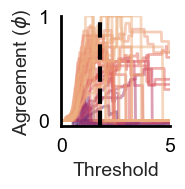

Example figure saved to /Users/wojemann/local_data/dynasd_data/FIGURES/threshold_tune_example_test_pretrained.pdf (HUP238 seizures: 3)


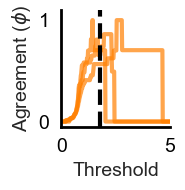

In [ ]:
# Generate threshold sweep plots for all seizures (LiNDDA_3_2 model)
# Using onset probability data from test validation results

def calculate_phi_from_prob_data(onset_prob_data, thresholds):
    """
    Calculate phi (MCC) at different thresholds using onset probability data.
    
    Parameters:
    -----------
    onset_prob_data : pd.DataFrame
        DataFrame with index=['probability', 'label'] and columns=channel names
    thresholds : np.array
        Array of threshold values to evaluate
    
    Returns:
    --------
    phi_vals : np.array
        Phi values at each threshold
    """
    # Extract probabilities and labels
    probs = onset_prob_data.loc['probability'].values
    labels = onset_prob_data.loc['label'].values.astype(bool)
    
    phi_vals = []
    for threshold in thresholds:
        # Predictions: channels with probability > threshold
        pred_bool = probs > threshold
        
        # Calculate Matthews Correlation Coefficient
        if len(pred_bool) == 0 or len(labels) == 0:
            phi_vals.append(np.nan)
        else:
            phi = matthews_corrcoef(labels, pred_bool)
            phi_vals.append(phi)
    
    return np.array(phi_vals)

# Create LiNDDA model instance to get pretrained threshold
lindda_model = LiNDDA(fs=256, w_size=1, w_stride=0.5, sequence_length=3, forecast_length=2)
# Get pretrained threshold (need to pass a dummy dataframe - method='pretrained' doesn't use the data)
# Create a minimal dummy dataframe for the method call
dummy_df = pd.DataFrame(np.random.rand(10, 5))
pretrained_threshold = lindda_model.get_threshold(dummy_df, method='pretrained',threshold_agg='mean')

# Filter for LiNDDA_3_2 model
lindda_data = test_data[(test_data.model_key == 'LiNDDA_seq3_fc2')].copy()

# Get unique seizures (patient + onset combinations)
# We'll use one row per seizure (they should have same onset_prob_data)
lindda_data_unique = lindda_data.drop_duplicates(subset=['patient', 'onset'])

# Use fixed thresholds from 0 to 5
thresholds = np.linspace(0, 5, 301)

# Calculate threshold sweeps for each seizure
sweep_data = []
for idx, row in lindda_data_unique.iterrows():
    if 'onset_prob_data' not in row or row.get('onset_prob_data') is None:
        continue
    
    onset_prob_data = row['onset_prob_data']
    
    # Calculate phi curve using fixed thresholds
    phi_vals = calculate_phi_from_prob_data(onset_prob_data, thresholds)
    
    # Get max phi for coloring
    max_phi = np.nanmax(phi_vals) if np.any(~np.isnan(phi_vals)) else np.nan
    
    sweep_data.append({
        'patient': row['patient'],
        'onset': row['onset'],
        'thresholds': thresholds,
        'phi_vals': phi_vals,
        'max_phi': max_phi
    })

# Sort by max_phi for sequential colormap ordering
sweep_data_sorted = sorted(sweep_data, key=lambda x: x['max_phi'] if not np.isnan(x['max_phi']) else -np.inf)

# Convert to long-form dataframe for seaborn
plot_data = []
for i, data in enumerate(sweep_data_sorted):
    thresholds_plot = data['thresholds']
    phi_vals = data['phi_vals']
    max_phi = data['max_phi']
    
    # Only include if we have valid phi values
    if np.any(~np.isnan(phi_vals)) and not np.isnan(max_phi):
        for thresh, phi_val in zip(thresholds_plot, phi_vals):
            if not np.isnan(phi_val):
                plot_data.append({
                    'threshold': thresh,
                    'phi': phi_val,
                    'max_phi': max_phi,
                    'seizure_id': f"{data['patient']}_{data['onset']}"
                })

plot_df = pd.DataFrame(plot_data)

# Create plot using seaborn
fig, ax = plt.subplots(figsize=(2.2,2))

# Use seaborn lineplot with units for each seizure and hue for coloring by max_phi
sns.lineplot(data=plot_df, 
             x='threshold', 
             y='phi', 
             units='seizure_id',
             hue='max_phi',
             palette='flare_r',
             linewidth=2,
             alpha=0.5,
             legend=False,
             estimator=None,
             ax=ax)

# Add vertical dashed line at pretrained threshold
ax.axvline(pretrained_threshold, linestyle='--', color='black', linewidth=3)

ax.set_ylabel('Agreement ($\phi$)')
ax.set_xlabel('Threshold')
ax.set_ylim([-0.05, 1])
ax.set_xlim([0, 5])
# Keep axes black
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')
ax.tick_params(colors='black')
sns.despine()

plt.tight_layout()
plt.savefig(ospj(figpath, 'threshold_sweep_all_seizures_lindda_3_2.pdf'), bbox_inches='tight')
print(f"Plotted {len(sweep_data_sorted)} threshold sweeps for LiNDDA_3_2 model")
print(f"Pretrained threshold: {pretrained_threshold:.4f}")
plt.show()

# Generate example figure for all HUP238 stim==0 seizures using seaborn
hup238_data = lindda_data_unique[lindda_data_unique.patient == 'HUP238']
if len(hup238_data) > 0:
    # Convert HUP238 data to long-form dataframe
    hup238_plot_data = []
    for idx, row in hup238_data.iterrows():
        if 'onset_prob_data' not in row or row.get('onset_prob_data') is None:
            continue
        
        onset_prob_data = row['onset_prob_data']
        phi_vals = calculate_phi_from_prob_data(onset_prob_data, thresholds)
        max_phi = np.nanmax(phi_vals) if np.any(~np.isnan(phi_vals)) else np.nan
        
        if np.any(~np.isnan(phi_vals)):
            for thresh, phi_val in zip(thresholds, phi_vals):
                if not np.isnan(phi_val):
                    hup238_plot_data.append({
                        'threshold': thresh,
                        'phi': phi_val,
                        'max_phi': max_phi,
                        'seizure_id': f"{row['patient']}_{row['onset']}"
                    })
    
    if len(hup238_plot_data) > 0:
        hup238_plot_df = pd.DataFrame(hup238_plot_data)
        
        fig, ax = plt.subplots(figsize=(2.2, 2))
        
        # Use seaborn lineplot
        sns.lineplot(data=hup238_plot_df,
                     x='threshold',
                     y='phi',
                     units='seizure_id',
                    #  hue='max_phi',
                    #  palette='Spectral',
                     color='#ff7f00',
                     linewidth=3,
                     alpha=0.7,
                     legend=False,
                     estimator=None,
                     ax=ax)
        
        # Mark pretrained threshold
        ax.axvline(pretrained_threshold, 
                  linestyle='--', 
                  color='black',
                  linewidth=3)
        
        # Add marker at pretrained threshold for first seizure
        first_seizure_id = hup238_plot_df['seizure_id'].iloc[0]
        first_seizure_data = hup238_plot_df[hup238_plot_df['seizure_id'] == first_seizure_id]
        pretrained_phi_idx = np.argmin(np.abs(first_seizure_data['threshold'].values - pretrained_threshold))
        pretrained_phi_val = first_seizure_data['phi'].iloc[pretrained_phi_idx]
        # ax.plot(pretrained_threshold, pretrained_phi_val, 
        #        'o', c='black',
        #        markersize=12,
        #        markeredgewidth=3,
            #    fillstyle='none')
        
        ax.set_ylabel('Agreement ($\phi$)')
        ax.set_xlabel('Threshold')
        ax.set_ylim([-0.05, 1.1])
        ax.set_xlim([0, 5])
        # ax.set_xticks([0,2.5,5])
        # Keep axes black
        ax.spines['bottom'].set_color('black')
        ax.spines['left'].set_color('black')
        ax.tick_params(colors='black')
        plt.tight_layout()
        sns.despine()
        
        fig_path = ospj(figpath, 'threshold_tune_example_test_pretrained.pdf')
        plt.savefig(fig_path, bbox_inches='tight')
        print(f"Example figure saved to {fig_path} (HUP238 seizures: {hup238_plot_df['seizure_id'].nunique()})")
        plt.show()

## Scalp EEG

In [4]:
all_dfs = []
for mdl_str in os.listdir(ospj(prodatapath,'results')):
    if (mdl_str == '.DS_Store') | ('GIN' in mdl_str):
        continue
    fold_path = ospj(prodatapath,'results',mdl_str)
    for csv_str in os.listdir(fold_path):
        # if 'samplewise'  not in csv_str:s
        if 'thres' in csv_str:
            continue
        data = pd.read_csv(ospj(fold_path,csv_str),encoding='latin-1').iloc[:-1,:]
        data['model'] = mdl_str
        data = data.rename(columns={'Unnamed: 0':'patient'})
        if 'auroc_sample_smooth' in data.columns:
            data['AUROC'] = data['auroc_sample_smooth']
            data['AUPRC'] = data['auprc_sample']
        elif 'auroc_sample' in data.columns:
            data['AUROC'] = data['auroc_sample']
            data['AUPRC'] = data['auprc_sample']
        
        all_dfs.append(data)
scalp_df = pd.concat(all_dfs)
scalp_df = scalp_df.iloc[:,:].reset_index(drop=True).dropna(subset='AUROC').reset_index(drop=True)
# Find duplicated rows by model, patient, and AUROC
num_duplicates = scalp_df.duplicated(subset=['model', 'patient', 'AUROC']).sum()

# Drop the duplicates
scalp_df = scalp_df.drop_duplicates(subset=['model', 'patient', 'AUROC']).reset_index(drop=True)

# all_ps = []
# x = scalp_df.pivot(index='patient',columns='model',values='AUROC')
# x
# for mdl in ['sparcnet','ramses','kaggle']:
#     res = sc.stats.wilcoxon(x.NDD,x[mdl],alternative='greater')
#     print(res)
#     all_ps.append(res[1])

In [5]:
import numpy as np
import scipy.stats as stats

# --- Performance Table: Single-model, separate for each relevant set/model-subset ---

mdl_order = ['kaggle', 'ramses', 'sparcnet', 'DynaSD-NDD-256-0.01-10min-final', 'DynaSD-LiNDDA-256-10min-54-final']
ln_models = ['DynaSD-NDD-256-0.01-10min-final', 'DynaSD-LiNDDA-256-10min-54-final']


def mean_ci(series, confidence=0.95):
    # 95% CI of the mean (Student t)
    n = series.count()
    m = series.mean()
    s = series.std(ddof=1)
    if n <= 1 or np.isnan(m) or np.isnan(s):
        return np.nan, np.nan
    t = stats.t.ppf((1 + confidence) / 2., n - 1)
    ci_halfwidth = t * s / np.sqrt(n)
    return m - ci_halfwidth, m + ci_halfwidth

def median_ci(series, confidence=0.95):
    # 95% CI for the median using bootstrap (more robust, esp for AUROC)
    # Use 10,000 bootstrap samples for some stability
    arr = series.dropna().values
    if len(arr) == 0:
        return np.nan, np.nan
    rng = np.random.default_rng(42)
    medians = []
    n_boot = 10000
    for _ in range(n_boot):
        sample = rng.choice(arr, size=len(arr), replace=True)
        medians.append(np.median(sample))
    lower = np.percentile(medians, 2.5)
    upper = np.percentile(medians, 97.5)
    return lower, upper


def auroc_table(df, model_subset, analysis_set, subset_name):
    grouped = df[df.model.isin(model_subset)].groupby('model')
    avg = grouped.AUROC.mean()
    med = grouped.AUROC.median()
    std = grouped.AUROC.std()
    n = grouped.AUROC.count()
    # Compute 95% CI for mean and for median
    mean_ci_l, mean_ci_u = [], []
    median_ci_l, median_ci_u = [], []
    for mdl in grouped.groups:
        s = grouped.get_group(mdl).AUROC
        l,u = mean_ci(s)
        mean_ci_l.append(l)
        mean_ci_u.append(u)
        l,u = median_ci(s)
        median_ci_l.append(l)
        median_ci_u.append(u)
    out = pd.DataFrame({'model': med.index,
                        'AUROC_mean': avg.values,
                        'AUROC_mean_ci_l': mean_ci_l,
                        'AUROC_mean_ci_u': mean_ci_u,
                        'AUROC_median': med.values,
                        'AUROC_median_ci_l': median_ci_l,
                        'AUROC_median_ci_u': median_ci_u,
                        'AUROC_std': std.values,
                        'AUROC_n': n.values})
    out['analysis_set'] = analysis_set
    out['subset'] = subset_name
    # Just the performance of single models (no comparisons)
    return out

# Partition the data (leave full flexibility for later)
old_set = scalp_df[~scalp_df.patient.str.contains('LTM')]
new_set = scalp_df[scalp_df.patient.str.contains('LTM')]

# Only create single-model performance tables (do not combine single/performance and pairwise/tests):
perf_table_old = auroc_table(old_set, mdl_order, 'old', 'all_models')
perf_table_new = auroc_table(new_set, ln_models, 'new', 'LiNDDA54_NDD')
perf_table_all = auroc_table(scalp_df, ln_models, 'old+new', 'LiNDDA54_NDD')

perf_column_order = [
    'model', 'AUROC_mean', 'AUROC_mean_ci_l', 'AUROC_mean_ci_u',
    'AUROC_median', 'AUROC_median_ci_l', 'AUROC_median_ci_u',
    'AUROC_std', 'AUROC_n', 'analysis_set', 'subset'
]
# Stack performance tables: Each row is a single model, each table is an (analysis_set, subset) partition
perf_df = pd.concat([perf_table_old[perf_column_order],
                     perf_table_new[perf_column_order],
                     perf_table_all[perf_column_order]],
                    ignore_index=True)

# --- Stats Table: Only between-model comparisons (no per-model stats) with explicit designations ---

from statsmodels.stats.multitest import multipletests
from scipy.stats import wilcoxon

# Define comparisons you want (you can repeat the logic for new, old, both sets as needed)
comparison_tests = []

# (example: just old+new, LiNDDA/NDD vs Kaggle/RAMSES/SpARCNet)
comp_analysis_set = 'old+new'
comp_subset = 'LiNDDA54_vs_benchmarks'
ndd_models = ln_models
benchmark_models = ['kaggle', 'ramses', 'sparcnet']

for ndd_model in ndd_models:
    for bench_model in benchmark_models:
        ndd_scores = scalp_df[scalp_df['model'] == ndd_model].set_index('patient').AUROC
        bench_scores = scalp_df[scalp_df['model'] == bench_model].set_index('patient').AUROC
        common_patients = ndd_scores.index.intersection(bench_scores.index)
        ndd_vals = ndd_scores.loc[common_patients]
        bench_vals = bench_scores.loc[common_patients]
        if len(ndd_vals) > 0 and len(bench_vals) > 0:
            t_stat, p_val = wilcoxon(ndd_vals, bench_vals, nan_policy='omit')
            mean_diff = ndd_vals.mean() - bench_vals.mean()
        else:
            t_stat, p_val, mean_diff = np.nan, np.nan, np.nan
        comparison_tests.append({
            'model': ndd_model,
            'benchmark_model': bench_model,
            'n_samples': len(common_patients),
            't_stat': t_stat,
            'mean_diff': mean_diff,
            'p_val': p_val,
            'analysis_set': comp_analysis_set,
            'subset': comp_subset
        })

# FDR (Benjamini-Hochberg) Correction for all comparisons in this set
p_vals = [r['p_val'] for r in comparison_tests]
if any(~np.isnan(p_vals)):
    # Only run correction if at least one test has a value; else leave NaN below
    reject, pvals_corr, alphacSidak, alphacBonf = multipletests(p_vals, method='fdr_bh')
else:
    pvals_corr = [np.nan] * len(comparison_tests)
rank_order = pd.Series(p_vals).rank(method='min').astype(int)

# Build stats table
stat_df = pd.DataFrame(comparison_tests)
stat_df['p_val_rank'] = rank_order.values
stat_df['p_val_fdr_bh'] = pvals_corr

# Keep only comparison columns: No AUROC_median/std/n/mean except comparison values;
# (but keep n_samples as sample count for the comparison itself)
stat_column_order = [
    'model', 'benchmark_model', 'n_samples', 't_stat', 'mean_diff', 'p_val', 'p_val_rank', 'p_val_fdr_bh',
    'analysis_set', 'subset'
]
stat_df = stat_df[stat_column_order]

# --- Save tables separately ---
perf_df.to_csv(ospj(prodatapath, 'scalp_model_performance_table.csv'), index=False)
stat_df.to_csv(ospj(prodatapath, 'scalp_model_stats_table.csv'), index=False)

# Print outputs for review, including CIs
print("=== AUROC median/std/n/mean + CIs by model and set ===")
print(perf_df)
print("\n=== Statistical between-models info (old+new, LiNDDA/NDD vs SpARCNet/RAMSES/Kaggle) ===")
print(stat_df)


=== AUROC median/std/n/mean + CIs by model and set ===
                              model  AUROC_mean  AUROC_mean_ci_l  \
0  DynaSD-LiNDDA-256-10min-54-final    0.798222         0.747486   
1   DynaSD-NDD-256-0.01-10min-final    0.801085         0.745074   
2                            kaggle    0.744253         0.701477   
3                            ramses    0.680579         0.630780   
4                          sparcnet    0.778205         0.728948   
5  DynaSD-LiNDDA-256-10min-54-final    0.681418         0.569881   
6   DynaSD-NDD-256-0.01-10min-final    0.690558         0.588442   
7  DynaSD-LiNDDA-256-10min-54-final    0.765516         0.717314   
8   DynaSD-NDD-256-0.01-10min-final    0.770138         0.720598   

   AUROC_mean_ci_u  AUROC_median  AUROC_median_ci_l  AUROC_median_ci_u  \
0         0.848957      0.842588           0.763184           0.896036   
1         0.857097      0.837181           0.760951           0.903676   
2         0.787029      0.767956          

model
DynaSD-LiNDDA-256-10min-32-final    0.800619
DynaSD-LiNDDA-256-10min-54-final    0.787219
DynaSD-NDD-256-0.01-10min-final     0.810494
kaggle                              0.745495
ramses                              0.635000
sparcnet                            0.728652
Name: AUROC, dtype: float64
                          ndd_model benchmark_model  n_samples  t_stat  \
0   DynaSD-NDD-256-0.01-10min-final          kaggle         50   358.0   
1   DynaSD-NDD-256-0.01-10min-final          ramses         50   143.0   
2   DynaSD-NDD-256-0.01-10min-final        sparcnet         50   439.0   
3  DynaSD-LiNDDA-256-10min-54-final          kaggle         50   393.0   
4  DynaSD-LiNDDA-256-10min-54-final          ramses         50   145.0   
5  DynaSD-LiNDDA-256-10min-54-final        sparcnet         50   466.0   

   mean_diff         p_val  p_val_rank  p_val_fdr_bh  
0   0.056416  6.325488e-03           3  1.265098e-02  
1   0.138715  2.472138e-07           1  8.517482e-07  
2   0.047866

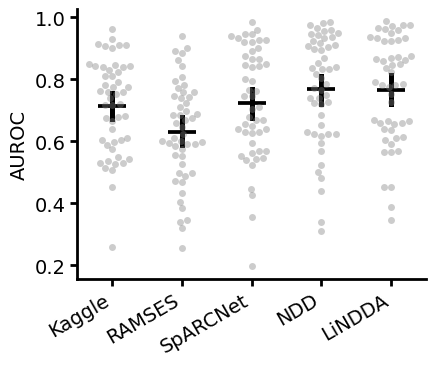

In [57]:
fig,ax = plt.subplots(figsize=(4.5,3.5))
mdl_order = ['kaggle', 'ramses', 'sparcnet','DynaSD-NDD-256-0.01-10min-final',  'DynaSD-LiNDDA-256-10min-54-final']
# sns.boxplot(scalp_df,x='model',y="AUROC",color='gray',order=mdl_order,width=.6,notch=True,fill=False)
sns.pointplot(scalp_df,x='model',y="AUROC",color='black',order=mdl_order,marker='_',markersize=20,estimator='mean',linestyle='none')
sns.swarmplot(scalp_df,x='model',y="AUROC",color='gray',order=mdl_order,alpha=0.4)
# sns.violinplot(scalp_df,x='model',y="AUROC",color='gray',order=mdl_order,fill=False)
# sns.pointplot(scalp_df,x='model',y="AUROC",palette='gray',order = mdl_order,marker='_',markersize=50,estimator='mean')
sns.despine()
plt.xlabel('')
plt.xticks(np.arange(len(mdl_order)),['Kaggle','RAMSES','SpARCNet','NDD','LiNDDA'],rotation=30,ha='right')
plt.savefig(ospj(figpath,'scalp_auc.pdf'),bbox_inches='tight',transparent=True)

# annotator = Annotator(ax,[('NDD','sparcnet'),('NDD','ramses'),('NDD','kaggle')],data=scalp_df,order=['kaggle','ramses','sparcnet','NDD'],x='model',y='AUROC')
# (annotator.configure(
#         test=None,
#         test_short_name='Wilx',
#         comparisons_correction="Benjamini-Hochberg",
#         loc='outside',
#         text_format='star',
#         fontsize=14,
#         pvalue_thresholds=[[1e-4, "****"], [1e-3, "***"],
#                         [1e-2, "**"], [0.05, "*"], [0.1, "x"],[1, "ns"]])
# .set_pvalues(
#     pvalues=all_ps
#     )
# )
# annotator.annotate()
# plt.savefig(ospj(figpath,'scalp_auc_annot.pdf'),bbox_inches='tight',transparent=True)

print(scalp_df.groupby('model').AUROC.median())
from scipy.stats import ttest_rel, wilcoxon
from statsmodels.stats.multitest import multipletests

# Define the NDD models and benchmark models based on mdl_order
ndd_models = ['DynaSD-NDD-256-0.01-10min-final', 'DynaSD-LiNDDA-256-10min-54-final']
benchmark_models = ['kaggle', 'ramses', 'sparcnet']

results = []

for ndd_model in ndd_models:
    for bench_model in benchmark_models:
        # Paired t-test: match by patient
        ndd_scores = scalp_df[scalp_df['model'] == ndd_model].set_index('patient').AUROC
        bench_scores = scalp_df[scalp_df['model'] == bench_model].set_index('patient').AUROC
        # Find intersection of patients
        common_patients = ndd_scores.index.intersection(bench_scores.index)
        ndd_vals = ndd_scores.loc[common_patients]
        bench_vals = bench_scores.loc[common_patients]
        # Perform paired t-test
        # t_stat, p_val = ttest_rel(ndd_vals, bench_vals, nan_policy='omit')
        t_stat, p_val = wilcoxon(ndd_vals, bench_vals, nan_policy='omit')
        results.append({
            'ndd_model': ndd_model,
            'benchmark_model': bench_model,
            'n_samples': len(common_patients),
            't_stat': t_stat,
            'mean_diff': ndd_vals.mean() - bench_vals.mean(),
            'p_val': p_val
        })

# FDR correction
p_vals = [r['p_val'] for r in results]
reject, pvals_corr, alphacSidak, alphacBonf = multipletests(p_vals, method='fdr_bh')
# Add ranks (lower p-value = higher rank, i.e., rank 1 for the lowest p)
rank_order = pd.Series(p_vals).rank(method='min').astype(int)

# Combine stats into dataframe
stat_df = pd.DataFrame(results)
stat_df['p_val_rank'] = rank_order.values
stat_df['p_val_fdr_bh'] = pvals_corr

# Reorder columns for clarity
stat_df = stat_df[['ndd_model', 'benchmark_model', 'n_samples', 't_stat', 'mean_diff', 'p_val', 'p_val_rank', 'p_val_fdr_bh']]

print(stat_df)
stat_df.to_csv(ospj(prodatapath, 'scalp_result_stats.csv'), index=False)

# for model in scalp_df.model.unique():
#     print(sc.stats.normaltest(scalp_df[scalp_df.model == model].AUROC)